In [1]:
import os
import sys
import dill
import pprint
from pathlib import Path
import itertools
import pathos
sys.path.append('/Users/leonardo.tessarolo/git/bayesian_bss/')

import math
import numpy as np
import jax.numpy as jnp
import functools
import pandas as pd
from numpyro.diagnostics import gelman_rubin
import scipy.stats as st
import time
import gc

from matplotlib import pyplot as plt
# import seaborn as sns

from dataclasses import dataclass, field
from typing import Callable, Dict, List, Optional, Sequence, Union
import warnings

import jax
import numpy as np
import pandas as pd

try:
    from tqdm import tqdm
    _HAS_TQDM = True
except ImportError:
    _HAS_TQDM = False

from src import MultivariateTPrior, ExponentialPrior, LoggingUtilities, StandardLogisticSource, StudentTSource, VisualizationUtilities, ContinuousExperimentExecutor
np.random.seed(100)

In [2]:
# Whether or not to create config
EXECUTE=True

# Whether or not to create folder structure
CREATE_FOLDER_STRUCTURE=True

# Experiment name
EXPERIMENT_NAME='importance_sampling_student_t_test'

# Folder which will contain output directory tree
OUTPUT_DIR='./output'
base_output_path=Path(OUTPUT_DIR)

# Create experiment directory
experiment_dir = base_output_path / EXPERIMENT_NAME
LoggingUtilities.configure_logging(
    log_dir=experiment_dir,
    log_type='continuous'
)

# 1. Configurations

In [3]:
# Number of sources and observations
NSOURCES=2
NOBS=100

# Mixing matrix configuration
A = np.array([
    [math.sqrt(2)/2, -math.sqrt(2)/2],
    [math.sqrt(2)/2, math.sqrt(2)/2]
])

# Ideal separating matrix
B = np.linalg.inv(A)

if EXECUTE:
    # Execution configurations
    exec_configs = {
        'general': {
            # General output directory
            'base_output_path': base_output_path,
            # Experiment name for folder structure
            'experiment_name': EXPERIMENT_NAME,
            # Experiment directory
            'experiment_dir': experiment_dir,
            # Whether or not to create folder structure
            'create_folder_structure': CREATE_FOLDER_STRUCTURE,
            # Whether or not to save graphs
            'save_graphs': False,
            # Number of sources
            'n_sources': NSOURCES,
            # Number of observations in each realization
            'n_obs': NOBS,
            # Number of parallel workers
            'n_workers': os.cpu_count(),
            # Number of parallel realizations to run
            'n_realizations': 5,
            # Mixing matrix
            'A': A,
            # Separating matrix
            'B': B,
            # Initial condition
            'initial_B': B,
            # Whether or not to use a normalized posterior
            'normalize_posterior': True,
            # Whether or not to have a progress bar for each initialization test case
            'initialization_progress_bar': False,
            # Whether or not to have a progress bar for each realization
            'realizations_progress_bar': True
        },
        'prior_variation':{
            'mode':{},
            'scale':{
                'base_prior': MultivariateTPrior(
                    center=B,
                    scale=1E-1,
                    df=3,
                    use_jax=True
                ),
                'target_param_values': np.logspace(
                    start=-1.5,
                    stop=1,
                    num=5,
                    base=10
                ),
                'target_param_fn': lambda target_params: [
                    MultivariateTPrior(
                        center=B,
                        scale=p,
                        df=3,
                        use_jax=True
                    ) for p in target_params
                ]
            },
            'tail_heaviness':{
                'base_prior': MultivariateTPrior(
                    center=B,
                    scale=0.1,
                    df=3,
                    use_jax=True
                ),
                'target_param_values': range(3,10),
                'target_param_fn': lambda target_params: [
                    MultivariateTPrior(
                        center=B,
                        scale=1,
                        df=p,
                        use_jax=True
                    ) for p in target_params
                ]
            },
        },
        'likelihood_variation':{},
        'prior_likelihood_variation':{},
        'mcmc': {
            # Initial condition noise
            'starting_distribution': lambda: st.t.rvs(
                loc=0,
                scale=0.05,
                df=3,
                size=B.shape
            ),
            # Exploration variance for MCMC
            'exploration_var': 1E-4,
            # Number of samples to generate
            'n_samples': 20000,
            # Number of parallel chains for MCMC
            'parallel_chains': 4,
            # Maximum iterations for MCMC
            'max_it': 15000,
            # Convergence threshold for R-hat diagnostic
            'R_hat_thresh': 1.01,
            # Interval at which R-hat will be evaluated
            'R_hat_evaluation_step': 500,
            # Number of consecutive convergent evaluations necessary
            'R_hat_persistance': 2,
            # Samples which will be discarded
            'R_hat_minimum_burn_in': 5000,
            # Whether or not to adjust exploration variance inside MCMC
            'auto_adjust_exploration_var': True,
            # Whether or not to show progress bars
            'progress_bar': False,
            # Target acceptance probability, in case auto adjust is enabled
            'target_accept_prob': 0.5,

        },
        'sources':{
            'rs1': StudentTSource(
                mu=0,
                sigma=math.sqrt(1/3),
                df=3,
                use_jax=True
            ),
            'rs2': StudentTSource(
                mu=0,
                sigma=math.sqrt(1/2),
                df=4,
                use_jax=True
            ),
            'rs3': StudentTSource(
                mu=0,
                sigma=math.sqrt(3/5),
                df=5,
                use_jax=True
            ),
            'rs4': StudentTSource(
                mu=0,
                sigma=math.sqrt(2/3),
                df=6,
                use_jax=True
            ),
            'rs5': StudentTSource(
                mu=0,
                sigma=math.sqrt(5/7),
                df=7,
                use_jax=True
            ),
            'rs6': StudentTSource(
                mu=0,
                sigma=math.sqrt(3/4),
                df=8,
                use_jax=True
            ),
            'rs7': StudentTSource(
                mu=0,
                sigma=math.sqrt(7/9),
                df=9,
                use_jax=True
            ),
            'rs8': StudentTSource(
                mu=0,
                sigma=math.sqrt(4/5),
                df=10,
                use_jax=True
            )
        }
    }
else:
    with (experiment_dir/'execution_config.pkl').open('rb') as f:
        exec_configs = dill.load(f)

pprint.pp(exec_configs)

{'general': {'base_output_path': PosixPath('output'),
             'experiment_name': 'importance_sampling_student_t_test',
             'experiment_dir': PosixPath('output/importance_sampling_student_t_test'),
             'create_folder_structure': True,
             'save_graphs': False,
             'n_sources': 2,
             'n_obs': 100,
             'n_workers': 8,
             'n_realizations': 5,
             'A': array([[ 0.70710678, -0.70710678],
       [ 0.70710678,  0.70710678]]),
             'B': array([[ 0.70710678,  0.70710678],
       [-0.70710678,  0.70710678]]),
             'initial_B': array([[ 0.70710678,  0.70710678],
       [-0.70710678,  0.70710678]]),
             'normalize_posterior': True,
             'initialization_progress_bar': False,
             'realizations_progress_bar': True},
 'prior_variation': {'mode': {},
                     'scale': {'base_prior': <src.prior.MultivariateTPrior object at 0x11d3ef4d0>,
                               'targe

# 2. Folder Structure

In [4]:
# Initialize folder structure, if so specified
if CREATE_FOLDER_STRUCTURE:
    if exec_configs['general']['create_folder_structure']:
        # Creates base output path and experiment dir
        if not base_output_path.is_dir():
            base_output_path.mkdir()
        if not experiment_dir.is_dir():
            experiment_dir.mkdir()

        # Creates initialization results folder
        initialization_dir = experiment_dir / 'initial_mode_seeking'
        if not initialization_dir.is_dir():
            initialization_dir.mkdir()

        # Creates folders for individual realizations
        for r in range(exec_configs['general']['n_realizations']):
            # Overall folder for realization
            realization_dir = experiment_dir / str(r)
            if not realization_dir.is_dir():
                realization_dir.mkdir()
            # Initialize success flag
            with (realization_dir/'success_flag.pkl').open('wb') as f:
                    dill.dump('UNFINISHED', f)
        

if EXECUTE:
     with (experiment_dir/'execution_config.pkl').open('wb') as f:
        dill.dump(exec_configs, f)


# 3. Executar Amostragem de Importância

In [5]:
if EXECUTE:
    ex = ContinuousExperimentExecutor(cfg=exec_configs)
    ex.run()

####################################################################################################
Total realizations: 5
Finished realizations: 0
Unfinished realizations: 5
####################################################################################################
Executando experimento


  0%|          | 0/5 [00:00<?, ?it/s]/Users/leonardo.tessarolo/git/bayesian_bss/src/estimator.py:1398: RuntimeWarning: overflow encountered in exp
  np.exp(temp, out=temp)
/Users/leonardo.tessarolo/git/bayesian_bss/src/estimator.py:1398: RuntimeWarning: overflow encountered in exp
  np.exp(temp, out=temp)
/Users/leonardo.tessarolo/git/bayesian_bss/src/estimator.py:1398: RuntimeWarning: overflow encountered in exp
  np.exp(temp, out=temp)
/Users/leonardo.tessarolo/git/bayesian_bss/src/estimator.py:1398: RuntimeWarning: overflow encountered in exp
  np.exp(temp, out=temp)
/Users/leonardo.tessarolo/git/bayesian_bss/src/estimator.py:1398: RuntimeWarning: overflow encountered in exp
  np.exp(temp, out=temp)
/Users/leonardo.tessarolo/git/bayesian_bss/src/estimator.py:1398: RuntimeWarning: overflow encountered in exp
  np.exp(temp, out=temp)
/Users/leonardo.tessarolo/git/bayesian_bss/src/estimator.py:1398: RuntimeWarning: overflow encountered in exp
  np.exp(temp, out=temp)
/Users/leonardo.te

In [6]:
with (experiment_dir/'0/results_raw.pkl').open('rb') as f:
    r = dill.load(f)

In [7]:
r['results']['prior_variation']['scale']['rs1'].keys()

dict_keys(['s', 'x', 'merged_baseline_samples', 'raw_baseline_samples', 'mcmc', 'targets', 'baseline', 'params', 'raw_weights', 'weights', 'k_hat', 'means', 'vars', 'skews', 'kurts'])

In [8]:
raise

RuntimeError: No active exception to reraise

# ContinuousExperimentParser

In [ ]:
class ContinuousExperimentParser:
    def __init__(
        self,
        experiment_dir
    ):
        # Save experiment dir
        self.experiment_dir = experiment_dir

        # # Test case to source map
        # self.test_case_source_map = {
        #     'i': 'perfect_model',
        #     'ii': 'perfect_model',
        #     'iii': 'perfect_model',
        #     'iv': 'perfect_model',
        #     'v': 'slightly_misspecified_model',
        #     'vi': 'slightly_misspecified_model',
        #     'vii': 'slightly_misspecified_model',
        #     'viii': 'slightly_misspecified_model',
        #     'ix': 'largely_misspecified_model',
        #     'x': 'largely_misspecified_model',
        #     'xi': 'largely_misspecified_model',
        #     'xii': 'largely_misspecified_model',
        # }


    def __read_execution_configs(self):
        # Read experiment configs
        with (self.experiment_dir/'execution_config.pkl').open('rb') as f:
                self.execution_config = dill.load(f)

    def __get_finished_realizations(
        self,
        verbose
    ):
        # Get realization dirs
        realizations = [x[1] for x in os.walk(self.experiment_dir)][0]
        realizations = [
            r for r in realizations if r not in [
                'analysis_all_realizations',
                'hypothesis_tests',
                'initial_mode_seeking'
            ]
        ]

        # Iterate in realizations and read success flags
        finished_realizations = []
        non_executed_realizations = []
        for r in realizations:
            # Get directory for realization
            realization_dir = self.experiment_dir / r

            # Read success flag
            with (realization_dir/'success_flag.pkl').open('rb') as f:
                success_flag = dill.load(f)

            if success_flag=='SUCCESS':
                finished_realizations.append(str(r))
            else:
                non_executed_realizations.append(str(r))
        
        self.finished_realizations = finished_realizations
        self.non_executed_realizations=non_executed_realizations
        
        if verbose:
            print('#'*100)
            print('Total of {} realizations with executed results'.format(len(finished_realizations)))
            print('-'*100)
            print('Total of {} realizations without executed results'.format(len(non_executed_realizations)))
            print('#'*100)


    def __parse_raw_results(
        self,
        verbose
    ):
        def __parse_prior_variation(
            mmse_estimator,
            s,
            x
        ):
            # Get MMSE estimate
            B_est_mmse = mmse_estimator.mcmc_results['B_est']

            # Get error for MMSE estimate
            mmse_error_norm = np.linalg.norm(
                np.subtract(
                    B_est_mmse,
                    self.execution_config['general']['B']
                )
            )/np.linalg.norm(self.execution_config['general']['B'])

            # Get estimated source
            s_est_mmse = B_est_mmse@x

            # Get error for estimated source
            s_est_error_norm = np.linalg.norm(
                np.subtract(
                    s_est_mmse,
                    s
                )
            )/np.linalg.norm(s)

            # Get R-hats
            diagnostics = mmse_estimator.diagnostics
            # diagnostics = mmse_estimator.R_hats
            converged = mmse_estimator.converged
            samples = mmse_estimator.samples

            return B_est_mmse, mmse_error_norm, s_est_mmse, s_est_error_norm, diagnostics, converged, samples

        def __parse_map(
            map_estimator,
            s,
            x
        ):
            # Get results for analyzed model (best model by default)
            B_est_map = map_estimator.gradient_ascent_results[0]['B_est']

            # Get error for MAP estimate
            map_error_norm = np.linalg.norm(
                np.subtract(
                    B_est_map,
                    self.execution_config['general']['B']
                )
            )/np.linalg.norm(self.execution_config['general']['B'])

            # Get estimated source
            s_est_map = B_est_map@x

            # Get error for estimated source
            s_est_error_norm = np.linalg.norm(
                np.subtract(
                    s_est_map,
                    s
                )
            )/np.linalg.norm(s)

            # Get execution logs
            logs = map_estimator.gradient_ascent_results[0]['logs']

            return B_est_map, map_error_norm, s_est_map, s_est_error_norm, logs
        
        def __parse_posteriori_grid(
            posteriori_grid,
            s,
            x
        ):
            
            # Get basis for symmetric space
            symmetric_basis = np.array([
                [0, 1],
                [1, 0]
            ])

            # Get basis for skew-symmetric space
            skew_symmetric_basis = np.array([
                [0, -1],
                [1, 0]
            ])

            # Get maximum u and v
            u_max = posteriori_grid.u_max
            v_max = posteriori_grid.v_max

            # Get results for posteriori grid
            B_est_posteriori = self.execution_config['general']['B'] + u_max*symmetric_basis + v_max*skew_symmetric_basis
            
            # Get recovered sources
            s_est_posteriori = B_est_posteriori@x

            # Get error for posteriori estimate
            posteriori_error_norm = np.linalg.norm(
                np.subtract(
                    B_est_posteriori,
                    self.execution_config['general']['B']
                )
            )/np.linalg.norm(self.execution_config['general']['B'])

            # Get error for estimated source
            s_est_error_norm = np.linalg.norm(
                np.subtract(
                    s_est_posteriori,
                    s
                )
            )/np.linalg.norm(s)

            return B_est_posteriori, posteriori_error_norm, s_est_posteriori, s_est_error_norm, u_max, v_max

        def __parse_realization(
            realization_name
        ):
            # Read raw results for realization
            realization_dir = self.experiment_dir / realization_name
            with (realization_dir/'results_raw.pkl').open('rb') as f:
                results_raw = dill.load(f)

            # Sources
            sources = list(
                self.execution_config['sources'].keys()
            )

            # Initialize dictionary to store parsed results
            parsed_results = {
                'realization': realization_name,
                'prior_variation': {}, 
                'likelihood_variation': {}, 
                'prior_likelihood_variation': {}
            }
        
            # Iterate through analysis types and retrieve results
            for analysis_type in parsed_results.keys():
                if analysis_type in results_raw['results'].keys():
                    parsed_results[analysis_type] = results_raw['results'][analysis_type]
            
            

            return parsed_results
        
        def __format_results(
            results
        ):
            # Test cases
            sources = list(
                self.execution_config['sim']['test_cases'].keys()
            )
            # Iterate in sources and results and create parsed dict with
            # sources as first dimension
            parsed_results = {
                s: {
                    'realization': [],
                    'prior_variation': {}, 
                    'likelihood_variation': {}, 
                    'prior_likelihood_variation': {}
                } for s in sources
            }

            prior_variations = self.execution_config['prior_variation'].keys()
            likelihood_variations = self.execution_config['likelihood_variation'].keys()
            prior_likelihood_variations = self.execution_config['prior_likelihood_variation'].keys()

            # Initialize prior variations fields
            if len(prior_variations)>0:
                for s in sources:
                    for prior_variation in prior_variations:
                        parsed_results[s]['prior_variation'][prior_variation] = {
                            's': [],
                            'x': [],
                            'merged_baseline_samples': [],
                            'raw_baseline_samples': [],
                            'mcmc_diagnostics': [],
                            'mcmc_logs': [],
                            'targets': [],
                            'baseline': [],
                            'params': [],
                            'raw_weights': [],
                            'weights': [],
                            'k_hat': [],
                            'means': [],
                            'vars': [],
                            'skews': [],
                            'kurts': []
                        }

            # Initialize likelihood variations fields
            if len(likelihood_variations)>0:
                pass

            # Initialize prior+likelihood variations fields
            if len(prior_likelihood_variations)>0:
                pass

            # Parse results and store realizations sequentially
            for r in results:
                for s in sources:
                    # Parse prior variations
                    if len(prior_variations)>0:
                        for prior_variation in prior_variations:
                            parsed_results[s]['prior_variation'][prior_variation]['s'].append(r['results']['prior_variation'][prior_variation][s]['s']) 
                            parsed_results[s]['prior_variation'][prior_variation]['x'].append(r['results']['prior_variation'][prior_variation][s]['x'])
                            parsed_results[s]['prior_variation'][prior_variation]['merged_baseline_samples'].append(r['results']['prior_variation'][prior_variation][s]['merged_baseline_samples'])
                            parsed_results[s]['prior_variation'][prior_variation]['mcmc_diagnostics'].append(r['results']['prior_variation'][prior_variation][s]['mcmc']['diagnostics'])
                            parsed_results[s]['prior_variation'][prior_variation]['mcmc_logs'].append(r['results']['prior_variation'][prior_variation][s]['mcmc']['logs'])
                            parsed_results[s]['prior_variation'][prior_variation]['targets'].append(r['results']['prior_variation'][prior_variation][s]['targets'])
                            parsed_results[s]['prior_variation'][prior_variation]['baseline'].append(r['results']['prior_variation'][prior_variation][s]['baseline'])
                            parsed_results[s]['prior_variation'][prior_variation]['params'].append(r['results']['prior_variation'][prior_variation][s]['params'])
                            parsed_results[s]['prior_variation'][prior_variation]['raw_weights'].append(r['results']['prior_variation'][prior_variation][s]['raw_weights'])
                            parsed_results[s]['prior_variation'][prior_variation]['weights'].append(r['results']['prior_variation'][prior_variation][s]['weights'])
                            parsed_results[s]['prior_variation'][prior_variation]['k_hat'].append(r['results']['prior_variation'][prior_variation][s]['k_hat'])
                            parsed_results[s]['prior_variation'][prior_variation]['means'].append(r['results']['prior_variation'][prior_variation][s]['means'])
                            parsed_results[s]['prior_variation'][prior_variation]['vars'].append(r['results']['prior_variation'][prior_variation][s]['vars'])
                            parsed_results[s]['prior_variation'][prior_variation]['skews'].append(r['results']['prior_variation'][prior_variation][s]['skews'])
                            parsed_results[s]['prior_variation'][prior_variation]['kurts'].append(r['results']['prior_variation'][prior_variation][s]['kurts'])
                    
                    # Parse likelihood variations
                    if len(likelihood_variations)>0:
                        pass

                    # Parse prior+likelihood variations
                    if len(prior_likelihood_variations)>0:
                        pass
            
            # Save to attribute
            self.parsed_results=parsed_results

        

        # Iterate over realizations and parse
        realizations_results = []
        for r in tqdm(self.finished_realizations):
            realizations_results.append( 
                __parse_realization(
                    realization_name=r
                )
            )

        # Put results in final parsed format
        __format_results(
            results=realizations_results
        )
            
            
    def parse(
        self,
        verbose=False
    ):
        
        # Read execution configurations
        self.__read_execution_configs()

        # Read raw results for realizations
        self.__get_finished_realizations(verbose=verbose)

        # Parse realizations results
        self.__parse_raw_results(verbose=verbose)

In [ ]:
parser=ContinuousExperimentParser(experiment_dir=experiment_dir)
parser.parse(verbose=True)


####################################################################################################
Total of 5 realizations with executed results
----------------------------------------------------------------------------------------------------
Total of 0 realizations without executed results
####################################################################################################


  0%|          | 0/5 [00:00<?, ?it/s]

> /var/folders/j_/fykf3k5959xcr2qglswycszm0000gn/T/ipykernel_61475/1984363590.py(220)__parse_realization()
    218             for analysis_type in parsed_results.keys():
    219 
--> 220                 import pdb; pdb.set_trace()
    221                 if analysis_type in results_raw['results'].keys():
    222                     parsed_results[analysis_type] = results_raw['results'][analysis_type]

*** NameError: name 'raw_results' is not defined
dict_keys(['rs1', 'rs2', 'rs3', 'rs4', 'rs5', 'rs6', 'rs7', 'rs8', 'results'])
dict_keys(['s', 'x'])


  0%|          | 0/5 [00:37<?, ?it/s]


# Amostras MCMC

In [ ]:
def IS_mcmc_diagnostics(
    results_is,
    B_true,
    test_cases=None,
    save_dir=None,
    save_name=None,
    label_size=20,
    legend_size=20,
):
    plt.rc(
        'legend',
        fontsize=legend_size,
        title_fontsize=legend_size
    )

    plt.rcParams['axes.facecolor'] = 'white'
    plt.rcParams['savefig.facecolor'] = 'white'

    plt.rc('axes', labelsize=label_size)
    plt.rc('xtick', labelsize=label_size)
    plt.rc('ytick', labelsize=label_size)

    parallel_chains = 4
    
    for analysis_type, analysis_results in results_is.items():
        # Plot chain evolutions
        fig, axs = plt.subplots(
            nrows=2, ncols=2,
            figsize=(25,20)
        )
        fig.suptitle(
            analysis_type,
            fontsize=25
        )
        samples_realizations = [analysis_results['raw_baseline_samples']]
        for i,j in np.ndindex(B_true.shape):
            for samples in samples_realizations:
                for c in range(parallel_chains):
                    axs[i,j].plot(
                        samples[c][:,i,j],
                        # label=c
                        linewidth=.5,
                        color='cornflowerblue'
                    )
            # axs[i,j].legend(
            #     fontsize=15
            # )
            axs[i,j].set_xlabel(
                'iteração',
                fontsize=15
            )
            axs[i,j].axhline(
                B_true[i,j],
                linestyle='--',
                color='gray'
            )
            axs[i,j].set_ylabel(
                'b{}{}'.format(
                    i+1,
                    j+1
                ),
            fontsize=15
    )

## Amostras MCMC

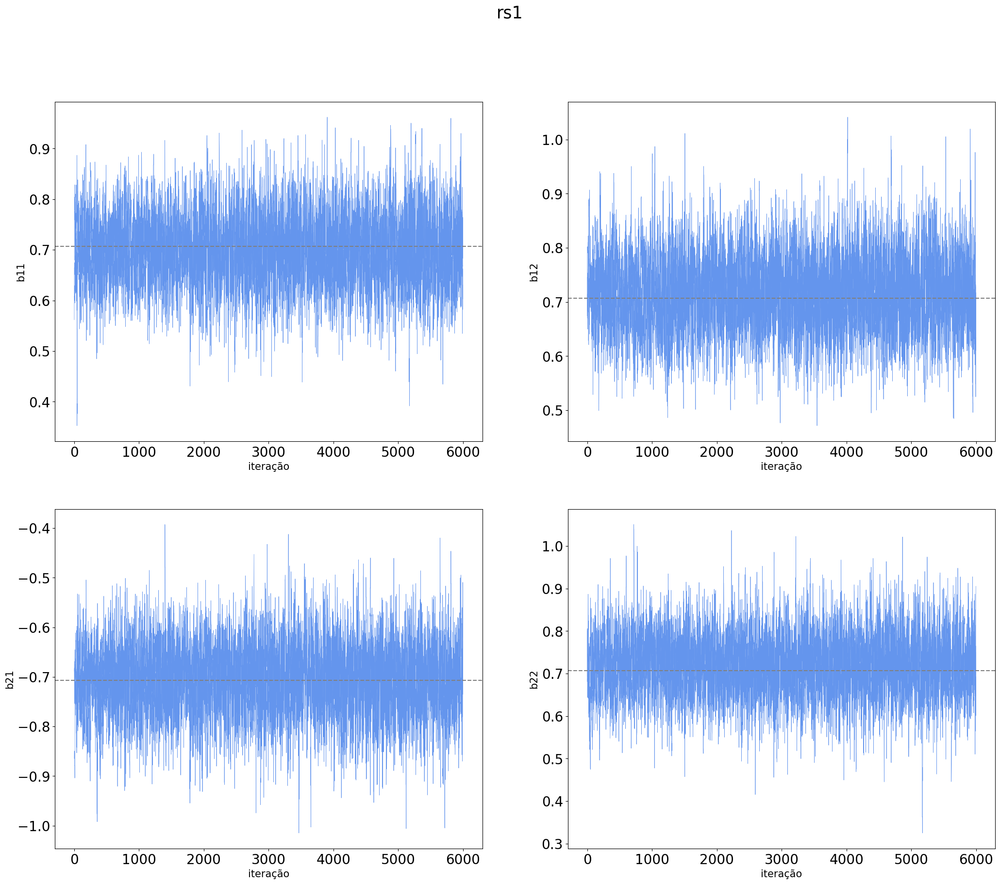

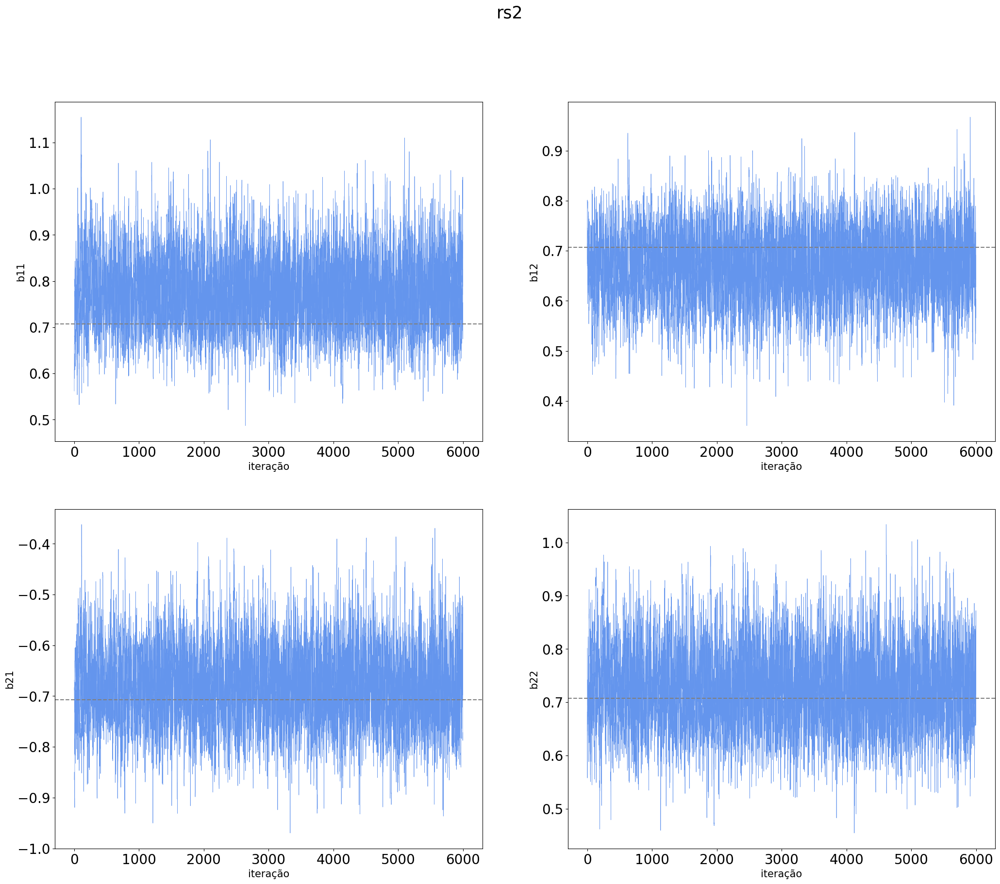

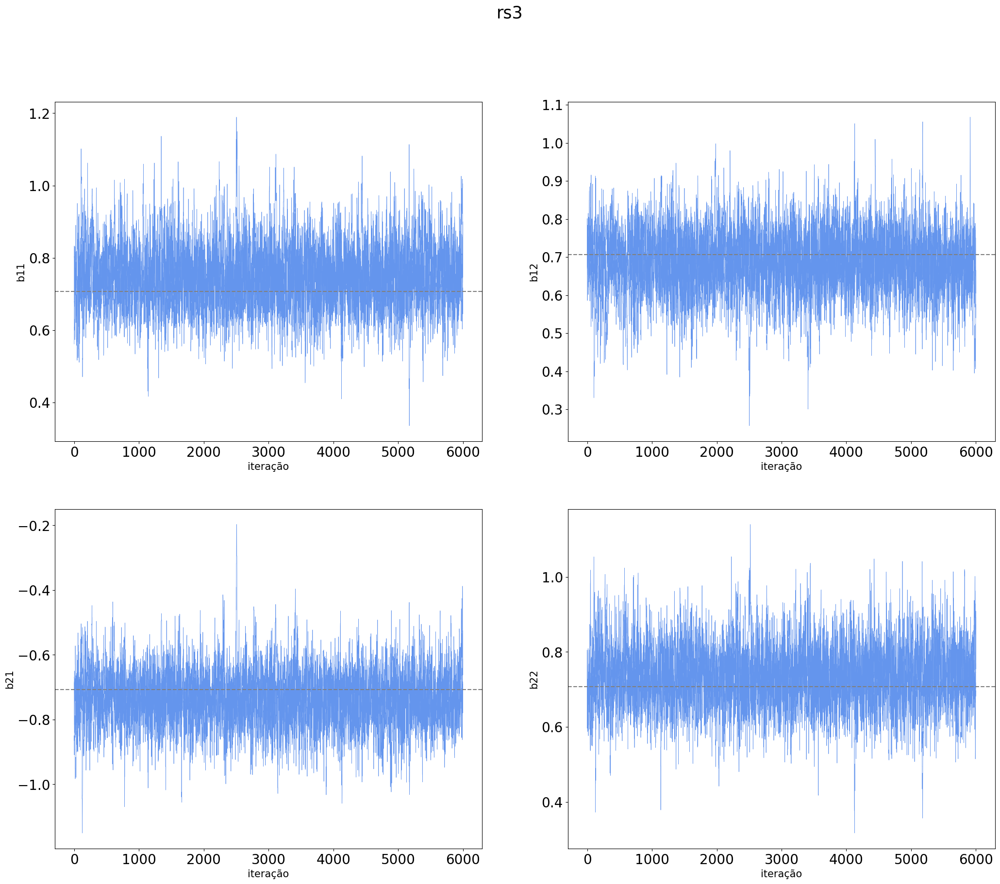

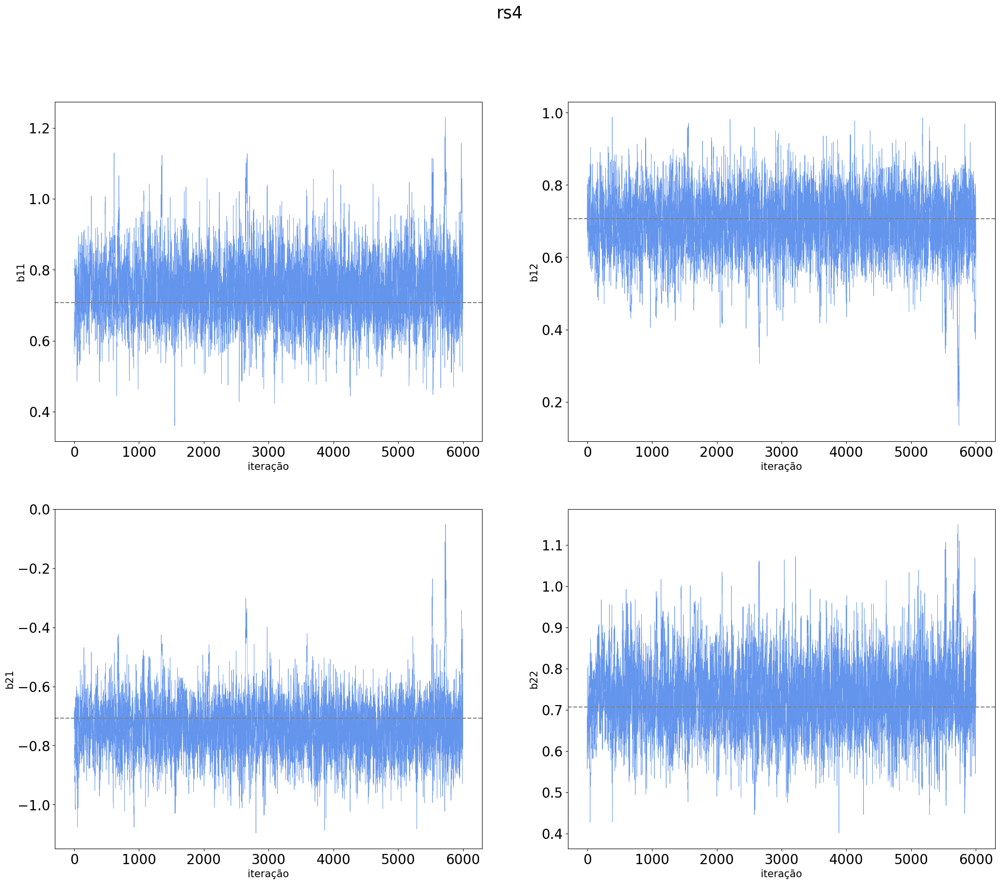

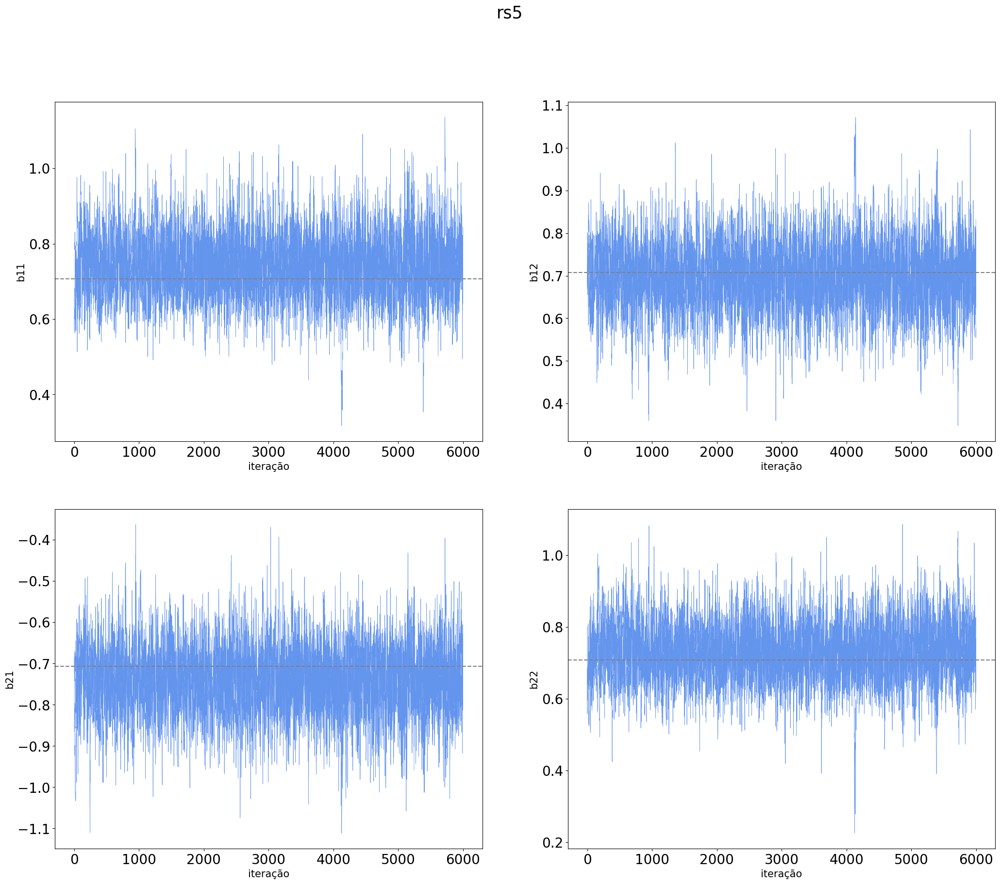

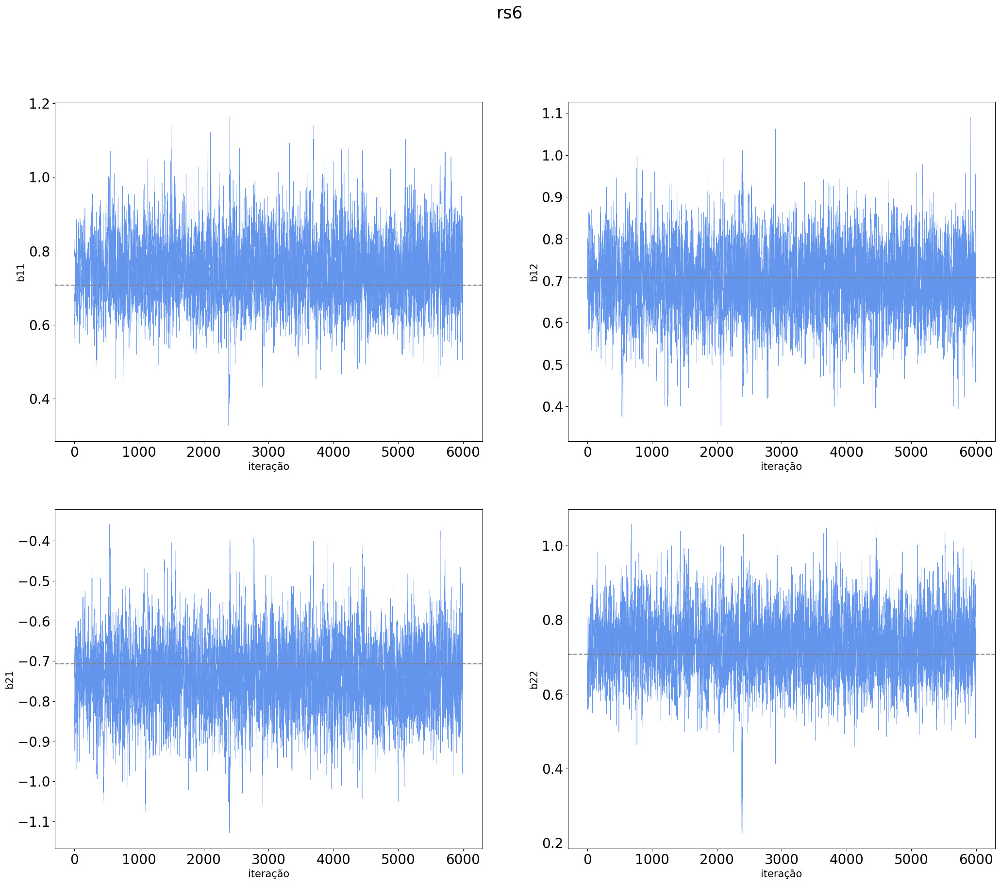

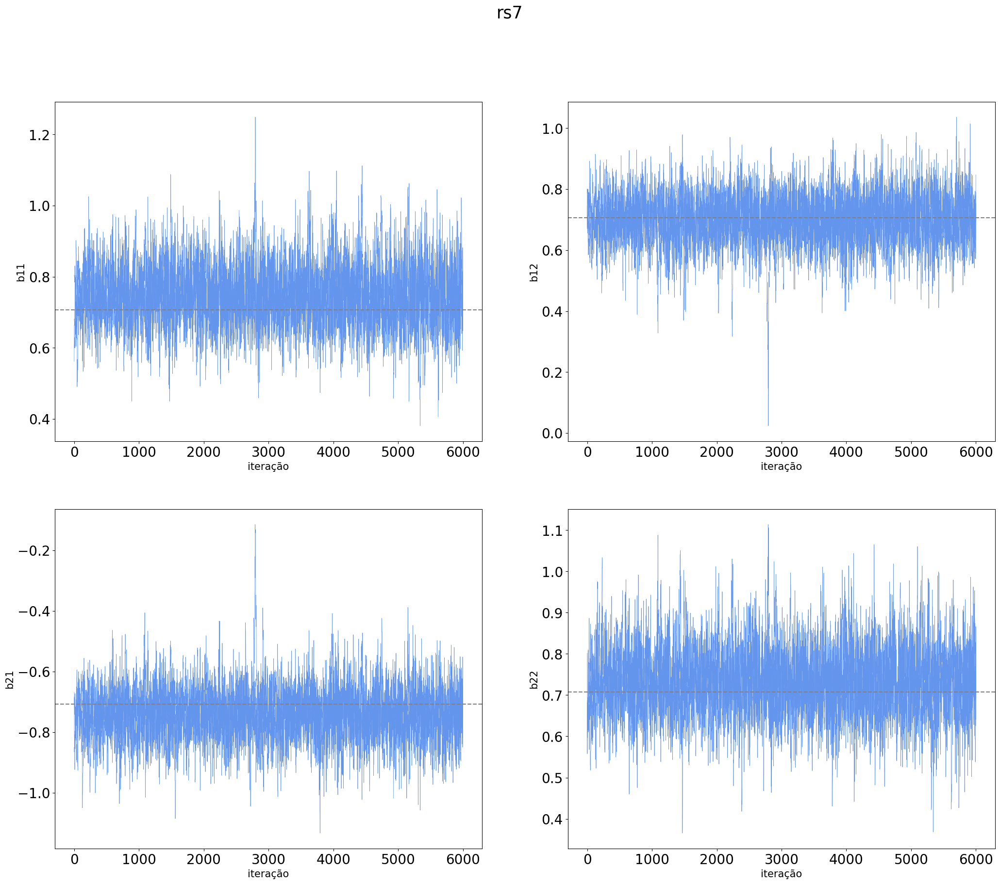

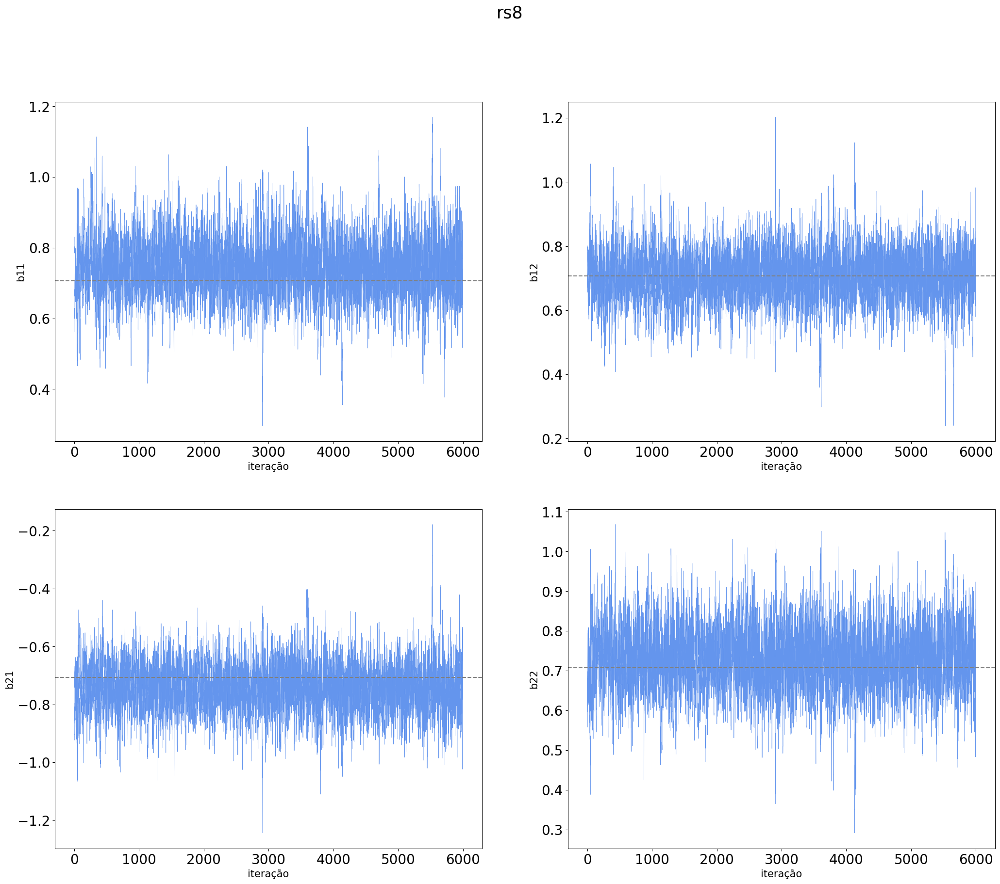

In [ ]:
VisualizationUtilities.IS_trace_plots(
    results_is=r['results']['prior_variation']['scale'],
    B_true=B
)

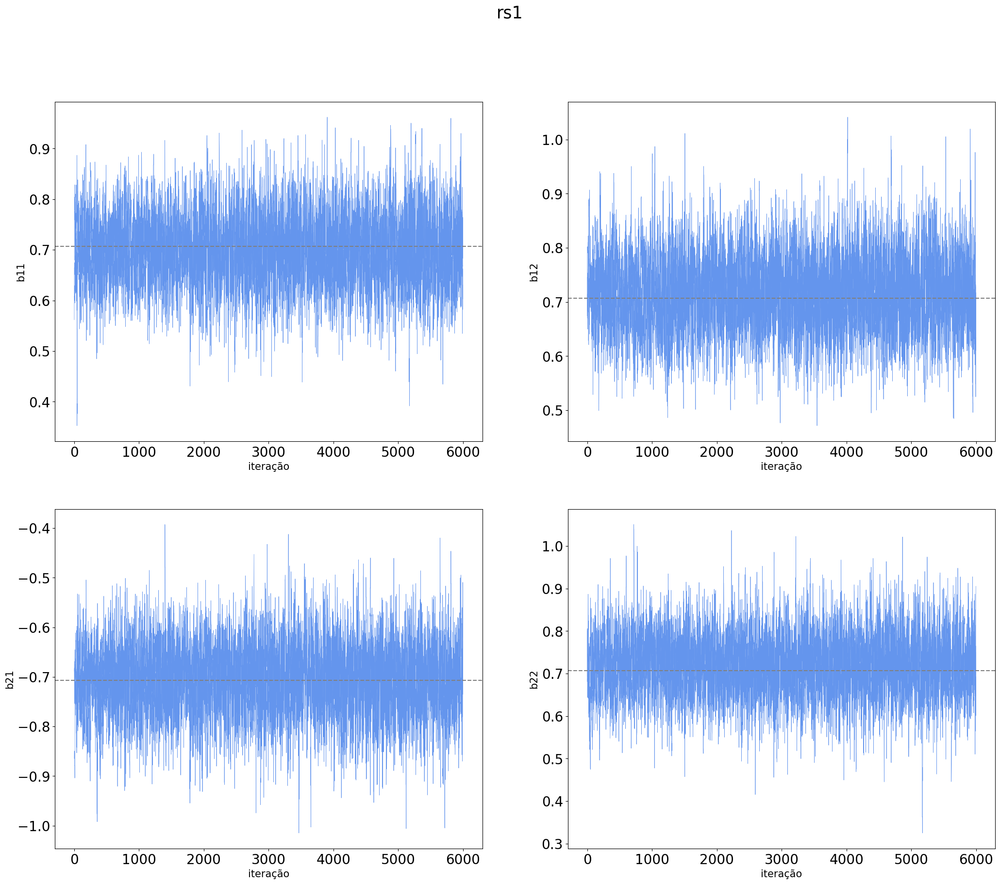

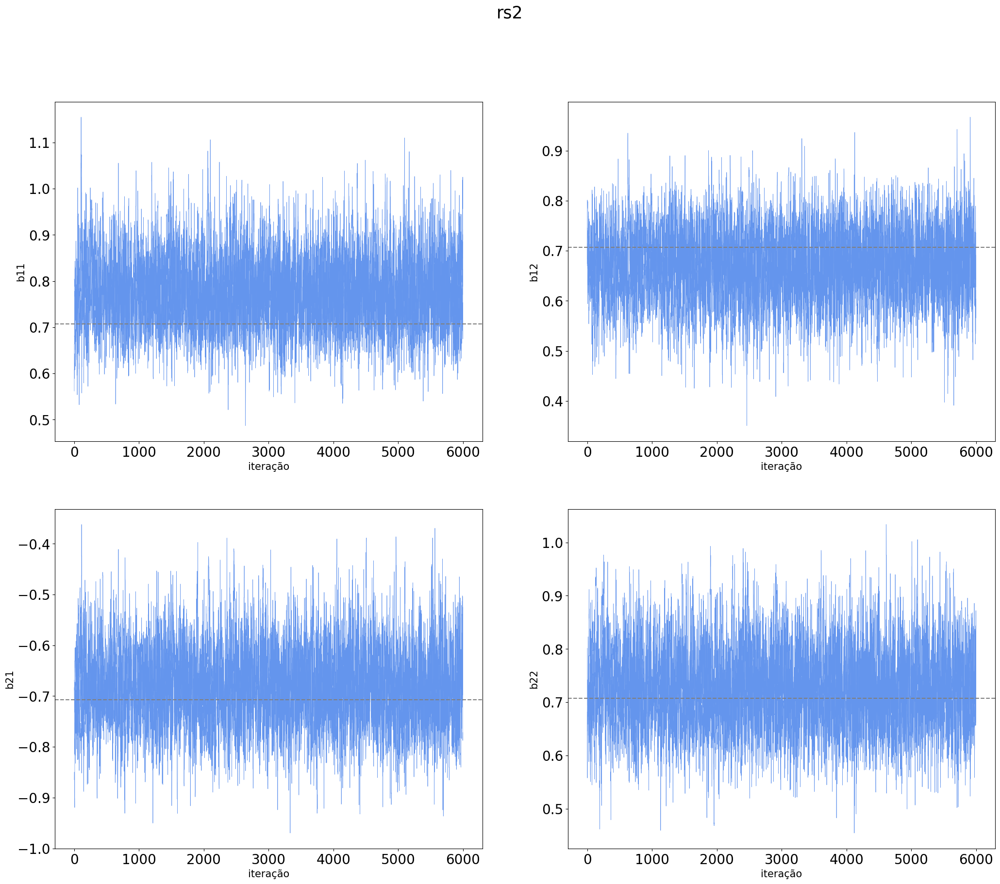

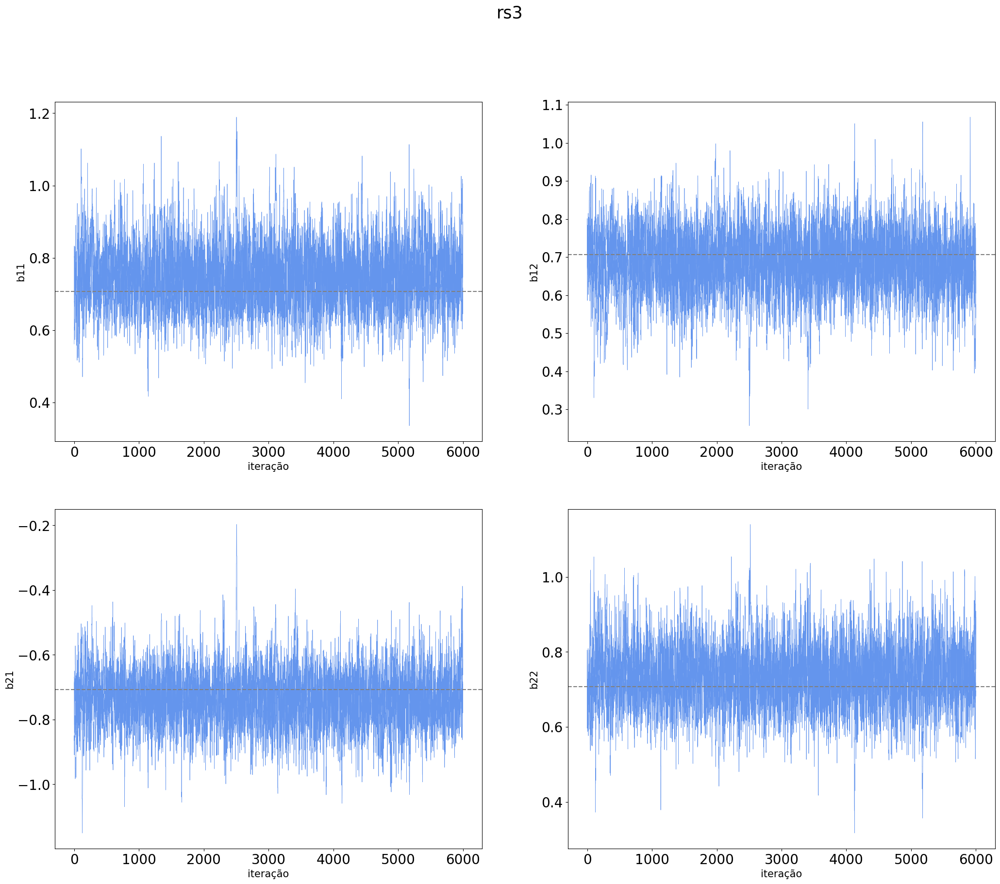

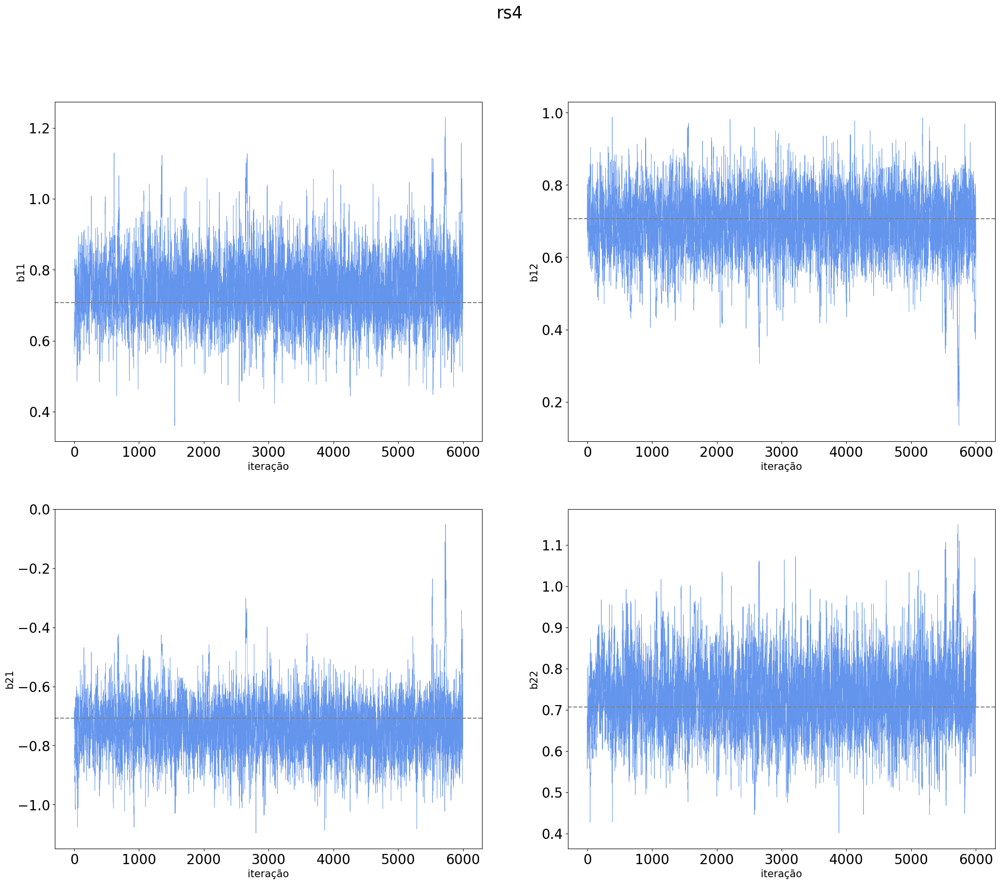

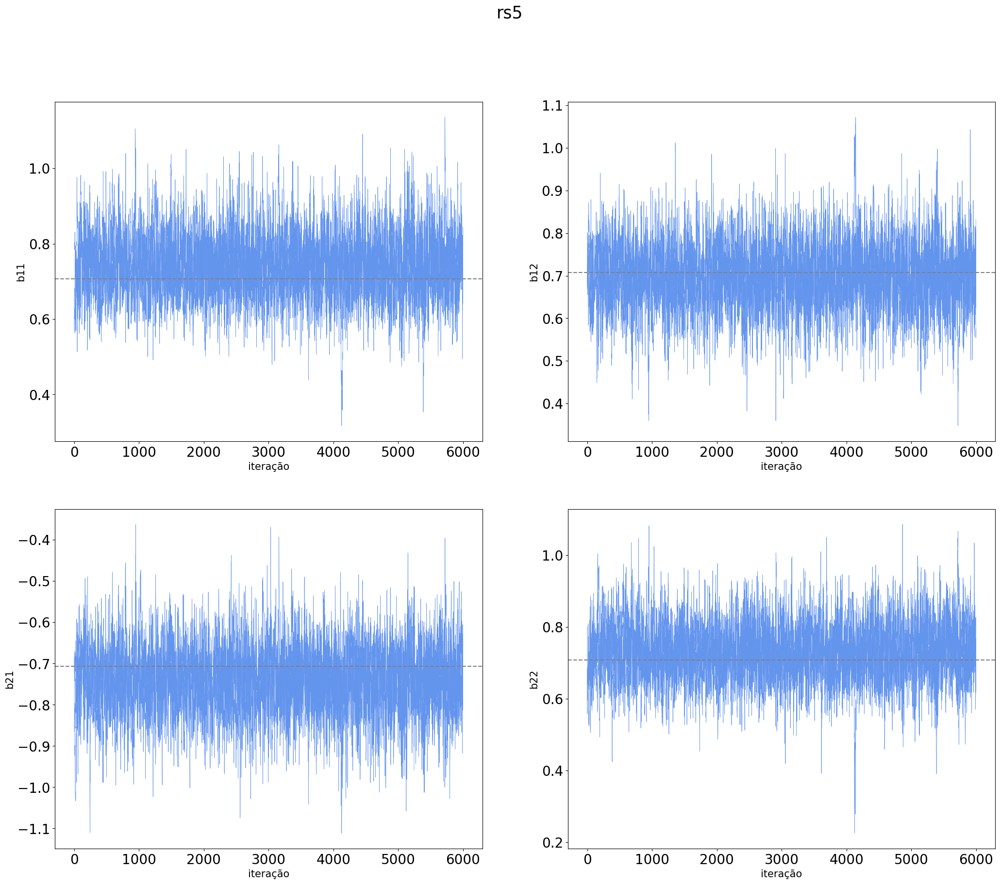

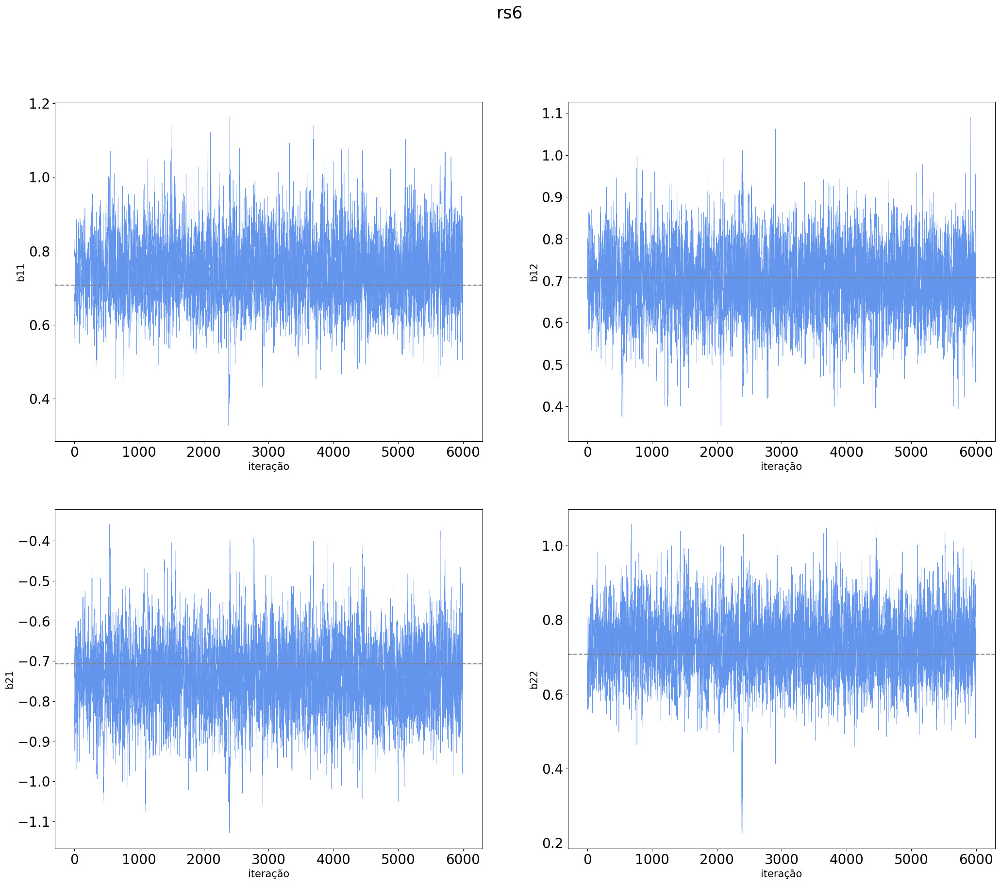

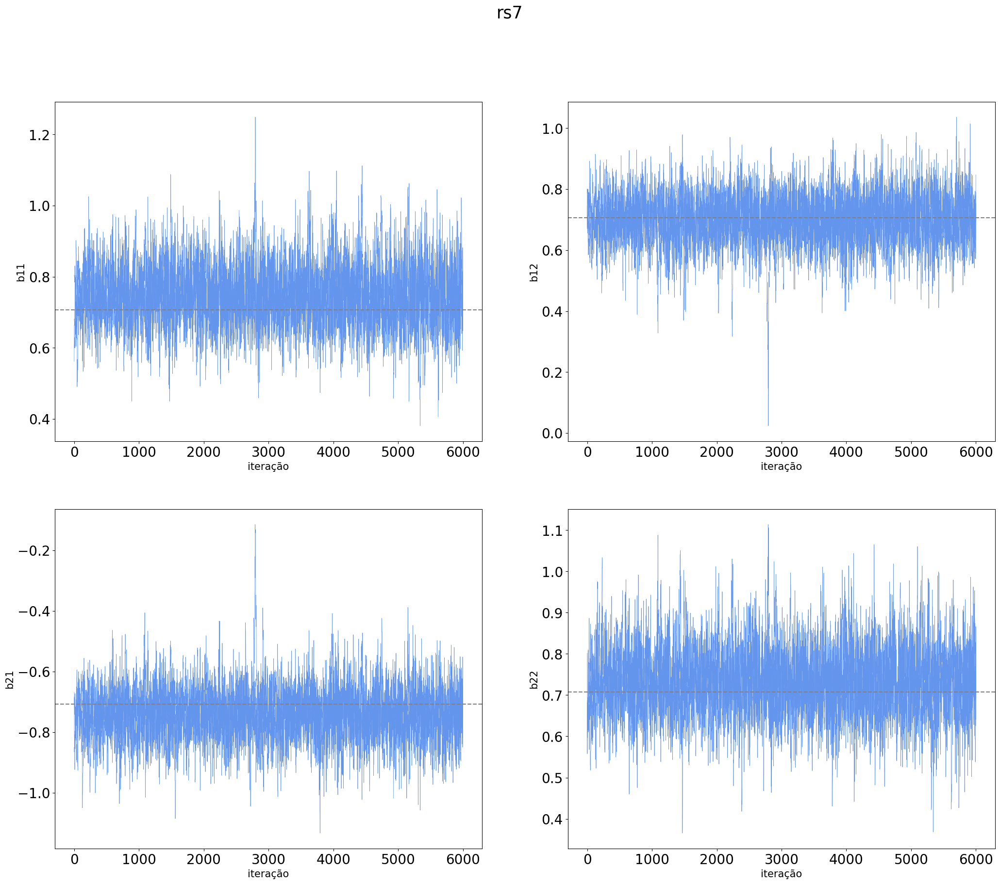

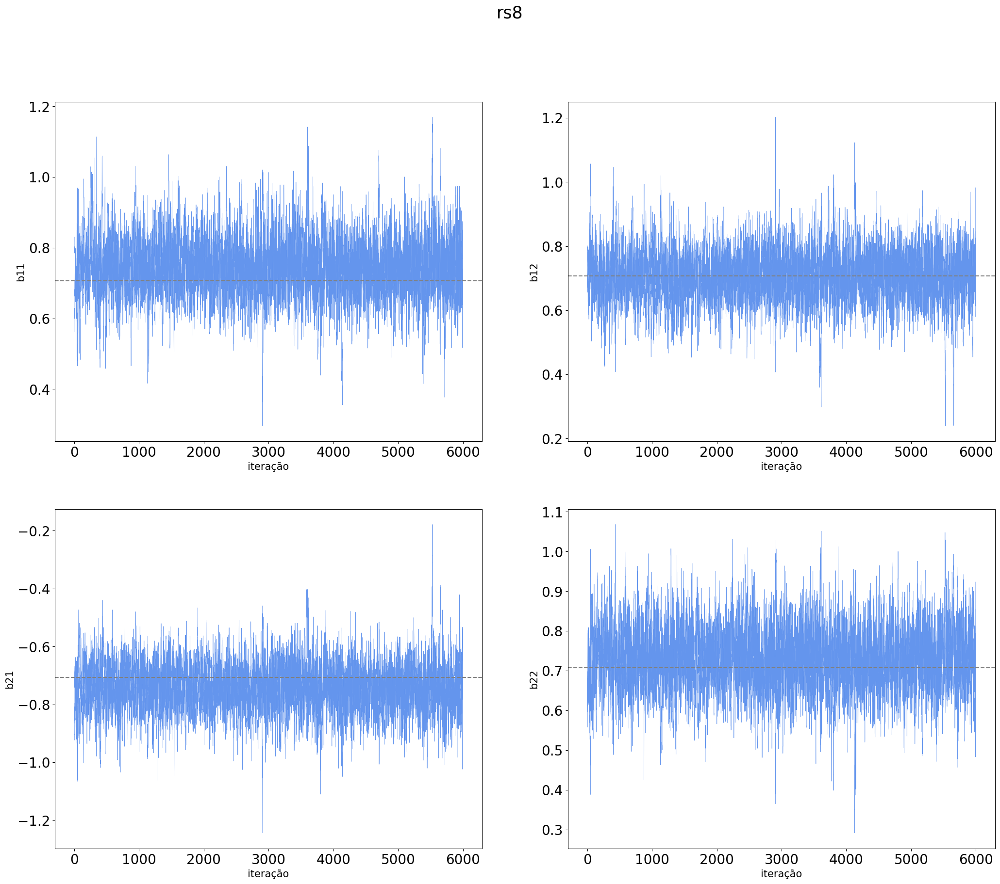

In [ ]:
VisualizationUtilities.IS_trace_plots(
    results_is=r['results']['prior_variation']['tail_heaviness'],
    B_true=B
)

## Diagnósticos MCMC

In [ ]:
print('-'*100)
print('R-HATS: PRIOR SCALE VARIATION')
print('-'*100)
pprint.pp({
   s: res['mcmc']['diagnostics'].iloc[-1,:][[c for c in res['mcmc']['diagnostics'].columns if 'r_hat' in c]] for s, res in r['results']['prior_variation']['scale'].items()
})

----------------------------------------------------------------------------------------------------
R-HATS: PRIOR SCALE VARIATION
----------------------------------------------------------------------------------------------------
{'rs1': r_hat_b_11    1.000590
r_hat_b_12    1.000804
r_hat_b_21    1.000319
r_hat_b_22    1.000237
Name: 1, dtype: float64,
 'rs2': r_hat_b_11    1.001028
r_hat_b_12    1.000915
r_hat_b_21    1.000687
r_hat_b_22    1.000094
Name: 1, dtype: float64,
 'rs3': r_hat_b_11    1.000979
r_hat_b_12    1.000149
r_hat_b_21    1.000042
r_hat_b_22    1.000685
Name: 1, dtype: float64,
 'rs4': r_hat_b_11    1.000329
r_hat_b_12    1.000266
r_hat_b_21    0.999977
r_hat_b_22    1.001149
Name: 1, dtype: float64,
 'rs5': r_hat_b_11    1.000133
r_hat_b_12    0.999972
r_hat_b_21    1.000085
r_hat_b_22    1.000208
Name: 1, dtype: float64,
 'rs6': r_hat_b_11    1.000704
r_hat_b_12    1.001149
r_hat_b_21    1.000636
r_hat_b_22    1.000579
Name: 1, dtype: float64,
 'rs7': r_hat_b_11

In [ ]:
print('-'*100)
print('ESS: PRIOR SCALE VARIATION')
print('-'*100)
pprint.pp({
   s: res['mcmc']['diagnostics'].iloc[-1,:][[c for c in res['mcmc']['diagnostics'].columns if 'ess' in c]] for s, res in r['results']['prior_variation']['scale'].items()
})

----------------------------------------------------------------------------------------------------
ESS: PRIOR SCALE VARIATION
----------------------------------------------------------------------------------------------------
{'rs1': ess_b_11    2972.843195
ess_b_12    3572.254035
ess_b_21    3269.734297
ess_b_22    3345.637506
Name: 1, dtype: float64,
 'rs2': ess_b_11    2715.304251
ess_b_12    2749.463089
ess_b_21    2694.663819
ess_b_22    3185.586992
Name: 1, dtype: float64,
 'rs3': ess_b_11    2173.535180
ess_b_12    2089.204619
ess_b_21    2194.239330
ess_b_22    2097.968049
Name: 1, dtype: float64,
 'rs4': ess_b_11    1860.183939
ess_b_12    1874.928087
ess_b_21    1739.878260
ess_b_22    1742.228397
Name: 1, dtype: float64,
 'rs5': ess_b_11    2211.654588
ess_b_12    2121.817843
ess_b_21    2096.132809
ess_b_22    2259.659045
Name: 1, dtype: float64,
 'rs6': ess_b_11    1824.903174
ess_b_12    2128.831954
ess_b_21    1972.733876
ess_b_22    2158.269791
Name: 1, dtype: float6

In [ ]:
print('-'*100)
print('R-HATS: PRIOR DF VARIATION')
print('-'*100)
pprint.pp({
   s: res['mcmc']['diagnostics'].iloc[-1,:][[c for c in res['mcmc']['diagnostics'].columns if 'r_hat' in c]] for s, res in r['results']['prior_variation']['tail_heaviness'].items()
})

----------------------------------------------------------------------------------------------------
R-HATS: PRIOR DF VARIATION
----------------------------------------------------------------------------------------------------
{'rs1': r_hat_b_11    1.000590
r_hat_b_12    1.000804
r_hat_b_21    1.000319
r_hat_b_22    1.000237
Name: 1, dtype: float64,
 'rs2': r_hat_b_11    1.001028
r_hat_b_12    1.000915
r_hat_b_21    1.000687
r_hat_b_22    1.000094
Name: 1, dtype: float64,
 'rs3': r_hat_b_11    1.000979
r_hat_b_12    1.000149
r_hat_b_21    1.000042
r_hat_b_22    1.000685
Name: 1, dtype: float64,
 'rs4': r_hat_b_11    1.000329
r_hat_b_12    1.000266
r_hat_b_21    0.999977
r_hat_b_22    1.001149
Name: 1, dtype: float64,
 'rs5': r_hat_b_11    1.000133
r_hat_b_12    0.999972
r_hat_b_21    1.000085
r_hat_b_22    1.000208
Name: 1, dtype: float64,
 'rs6': r_hat_b_11    1.000704
r_hat_b_12    1.001149
r_hat_b_21    1.000636
r_hat_b_22    1.000579
Name: 1, dtype: float64,
 'rs7': r_hat_b_11   

In [ ]:
print('-'*100)
print('ESS: PRIOR DF VARIATION')
print('-'*100)
pprint.pp({
   s: res['mcmc']['diagnostics'].iloc[-1,:][[c for c in res['mcmc']['diagnostics'].columns if 'ess' in c]] for s, res in r['results']['prior_variation']['tail_heaviness'].items()
})

----------------------------------------------------------------------------------------------------
ESS: PRIOR DF VARIATION
----------------------------------------------------------------------------------------------------
{'rs1': ess_b_11    2972.843195
ess_b_12    3572.254035
ess_b_21    3269.734297
ess_b_22    3345.637506
Name: 1, dtype: float64,
 'rs2': ess_b_11    2715.304251
ess_b_12    2749.463089
ess_b_21    2694.663819
ess_b_22    3185.586992
Name: 1, dtype: float64,
 'rs3': ess_b_11    2173.535180
ess_b_12    2089.204619
ess_b_21    2194.239330
ess_b_22    2097.968049
Name: 1, dtype: float64,
 'rs4': ess_b_11    1860.183939
ess_b_12    1874.928087
ess_b_21    1739.878260
ess_b_22    1742.228397
Name: 1, dtype: float64,
 'rs5': ess_b_11    2211.654588
ess_b_12    2121.817843
ess_b_21    2096.132809
ess_b_22    2259.659045
Name: 1, dtype: float64,
 'rs6': ess_b_11    1824.903174
ess_b_12    2128.831954
ess_b_21    1972.733876
ess_b_22    2158.269791
Name: 1, dtype: float64,


## Variação de escala

/Users/leonardo.tessarolo/git/bayesian_bss/src/visualizations.py:843: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax3.legend()


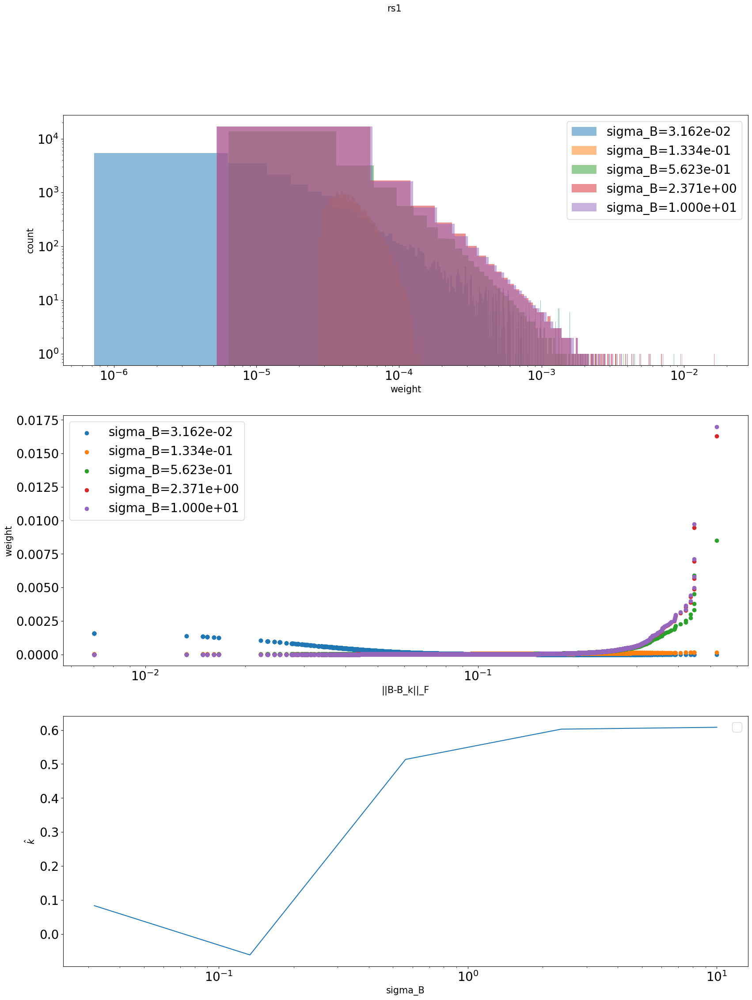

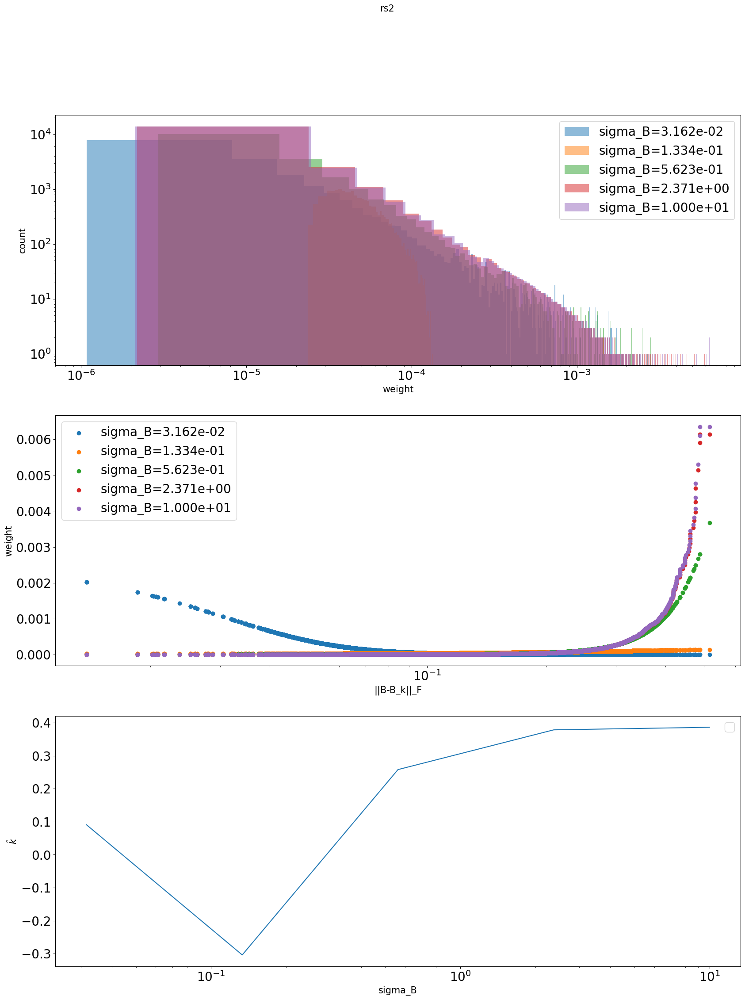

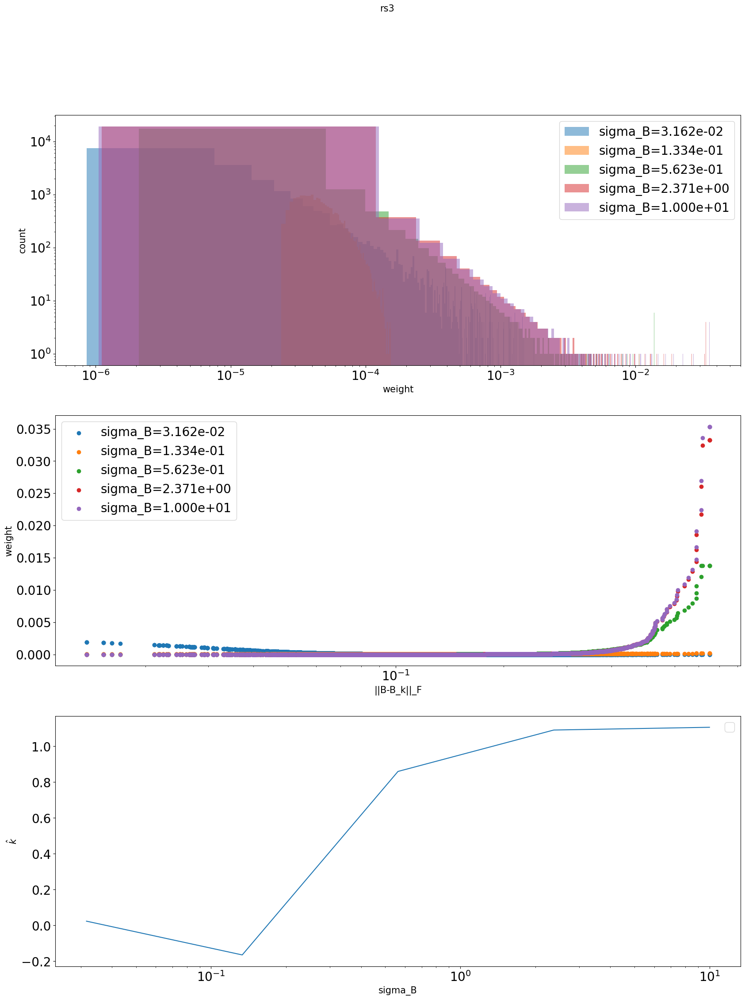

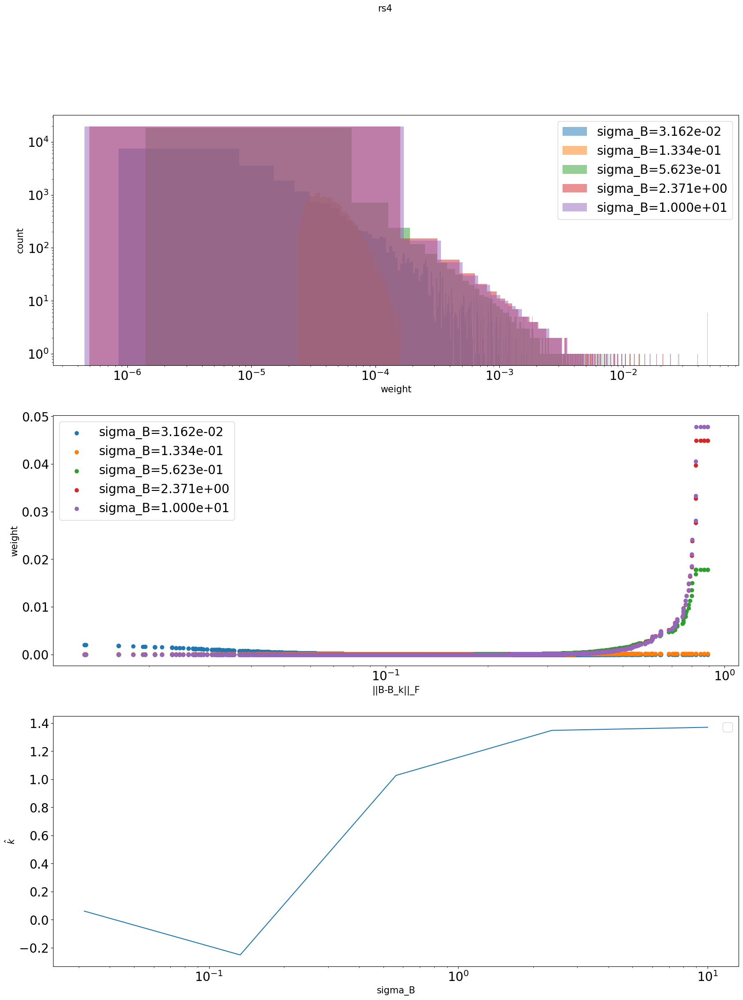

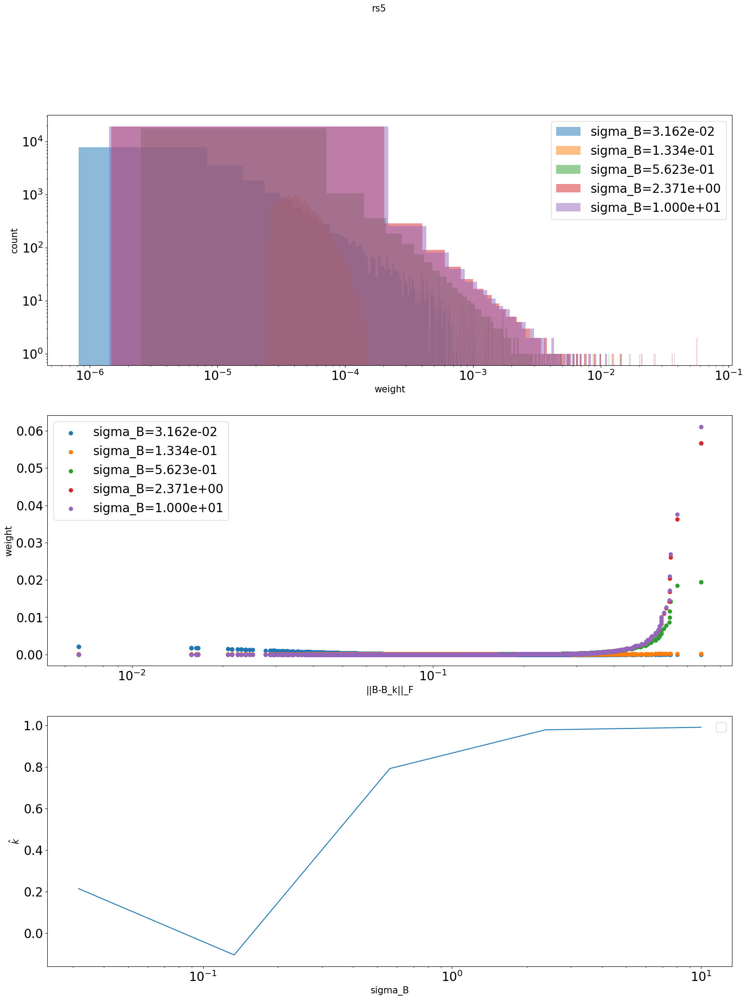

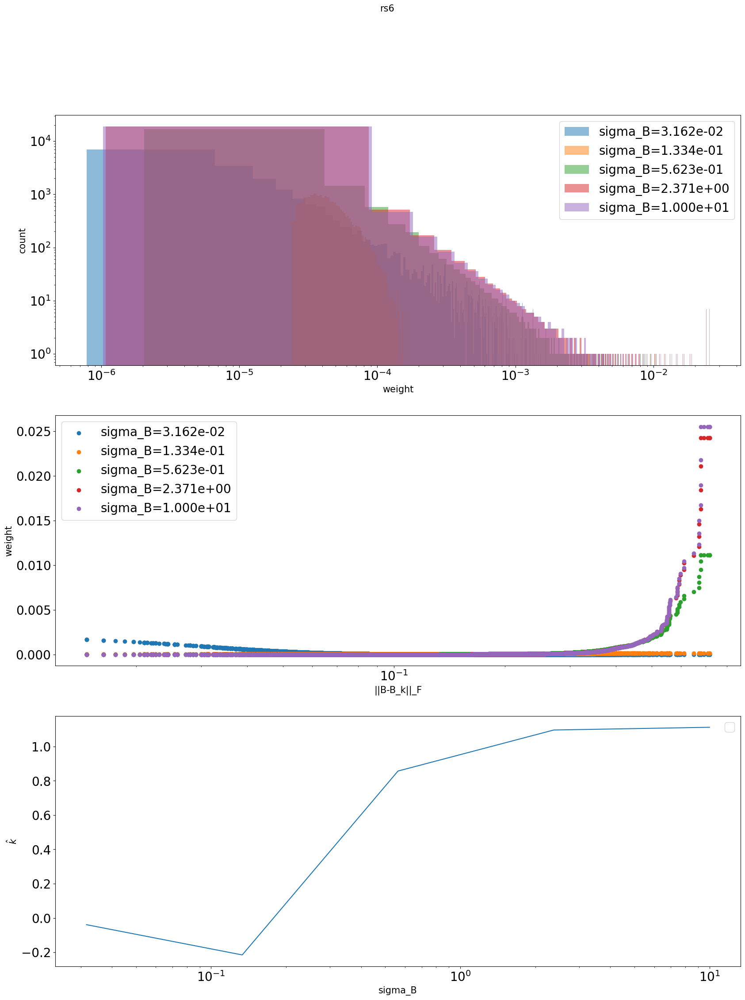

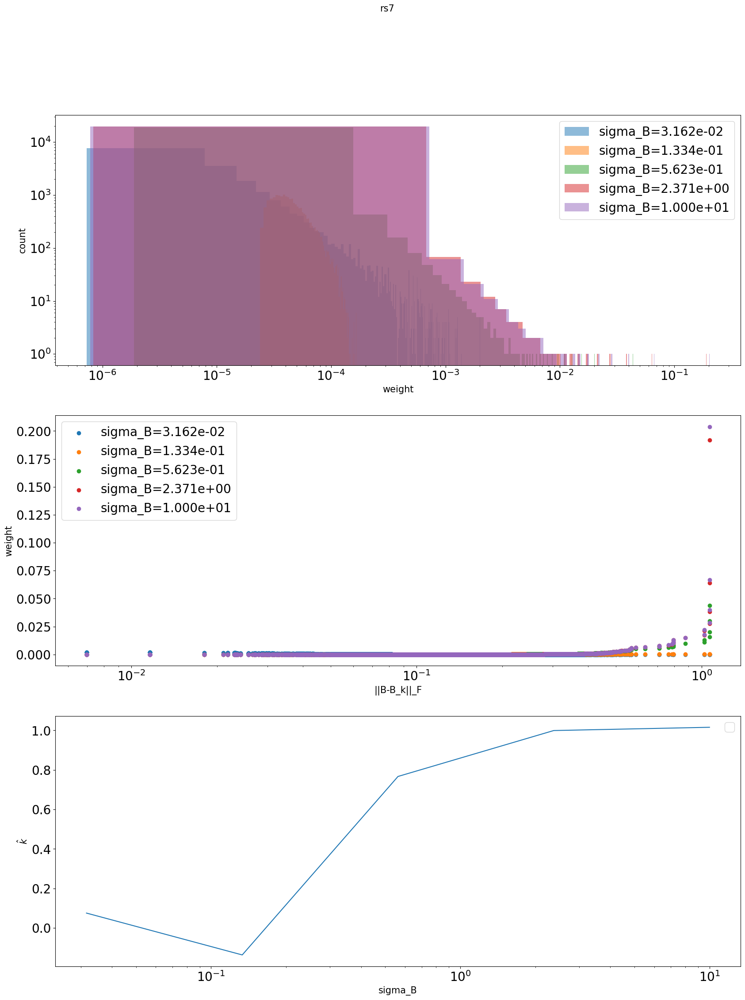

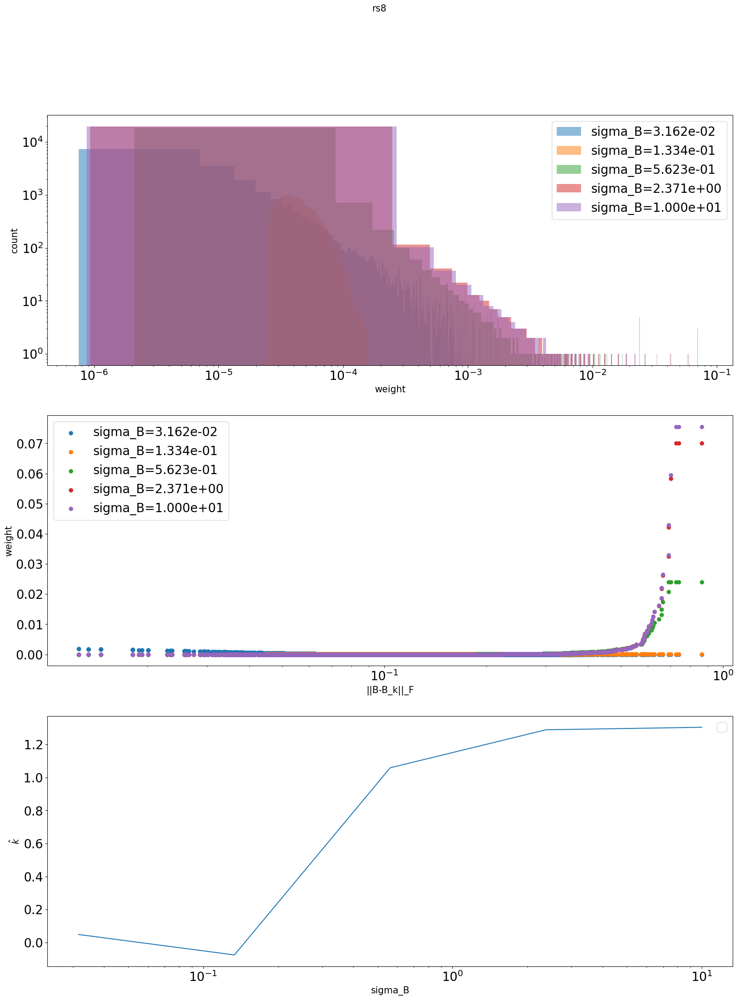

In [ ]:
VisualizationUtilities.visualize_IS_weights(
    results_is=r['results']['prior_variation']['scale'],
    true_B=B,
    param_name='sigma_B',
    alpha=0.5,
    n_curves=10
)

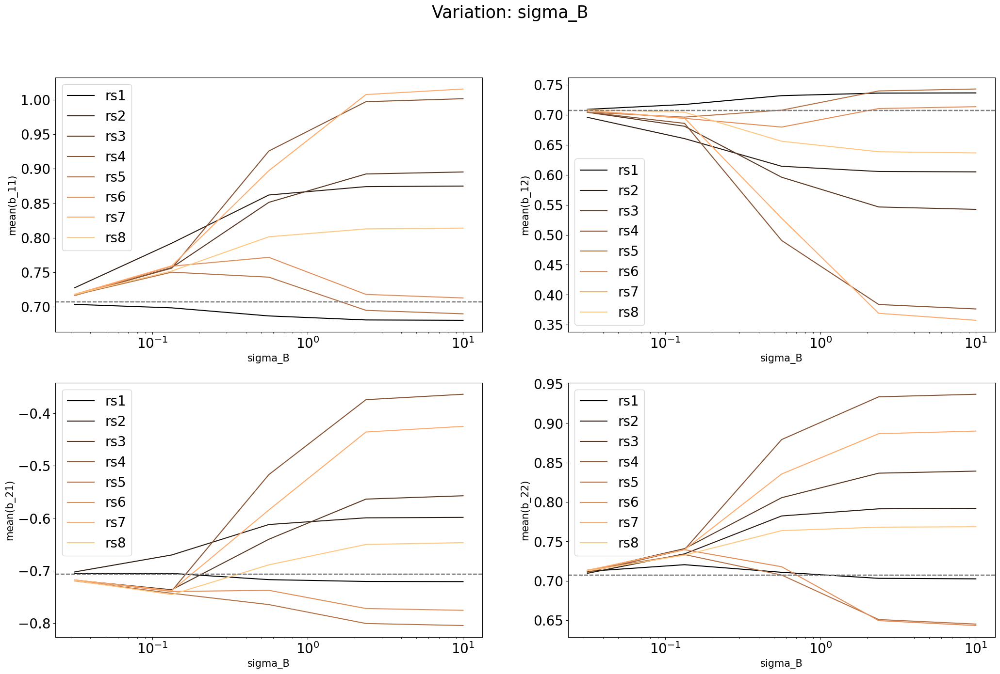

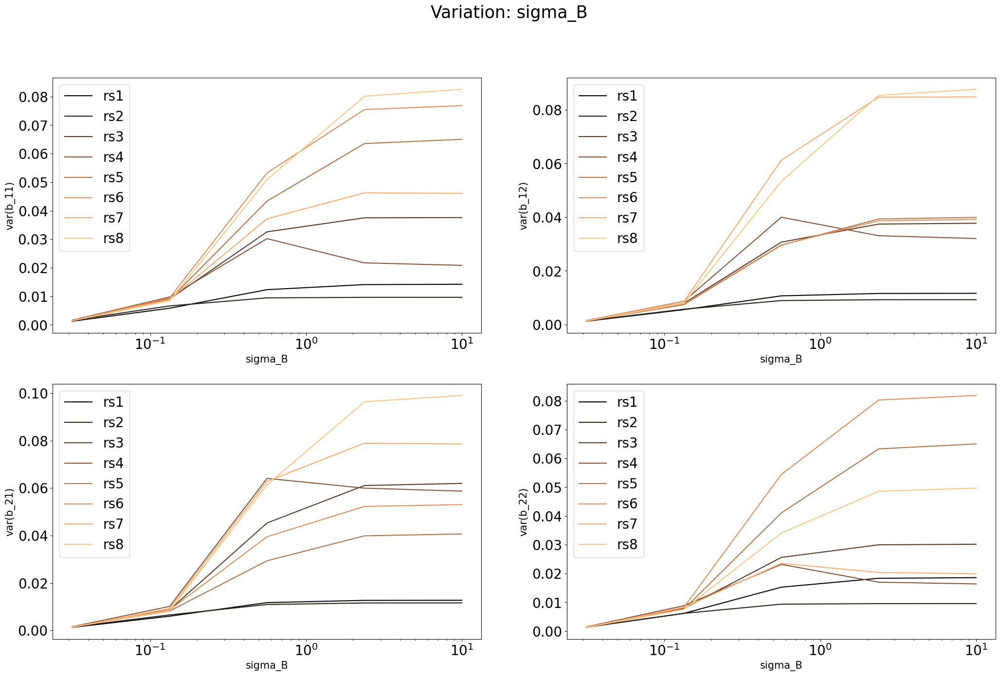

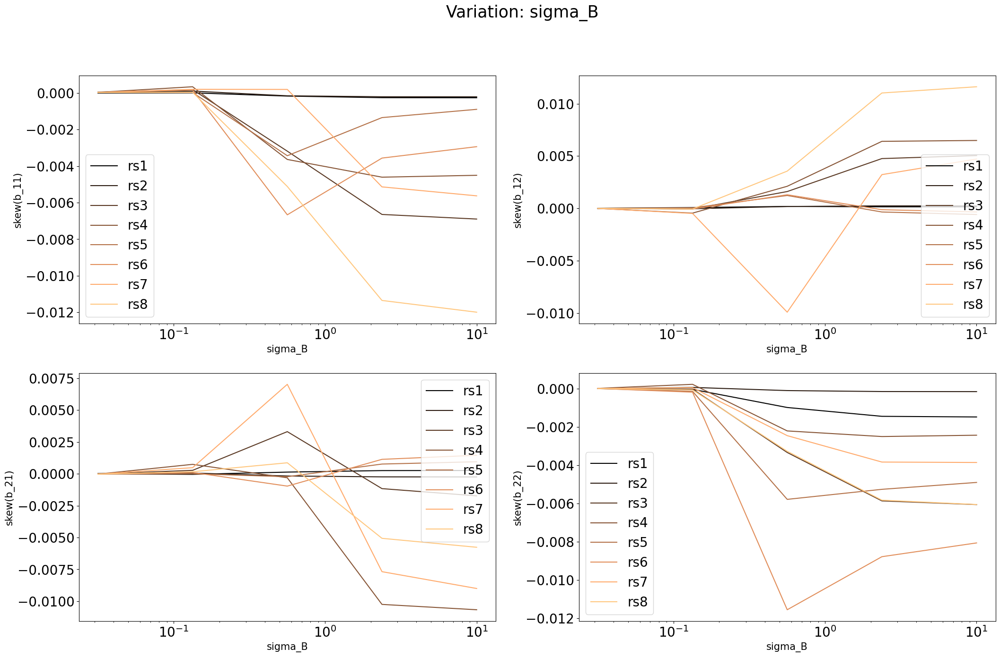

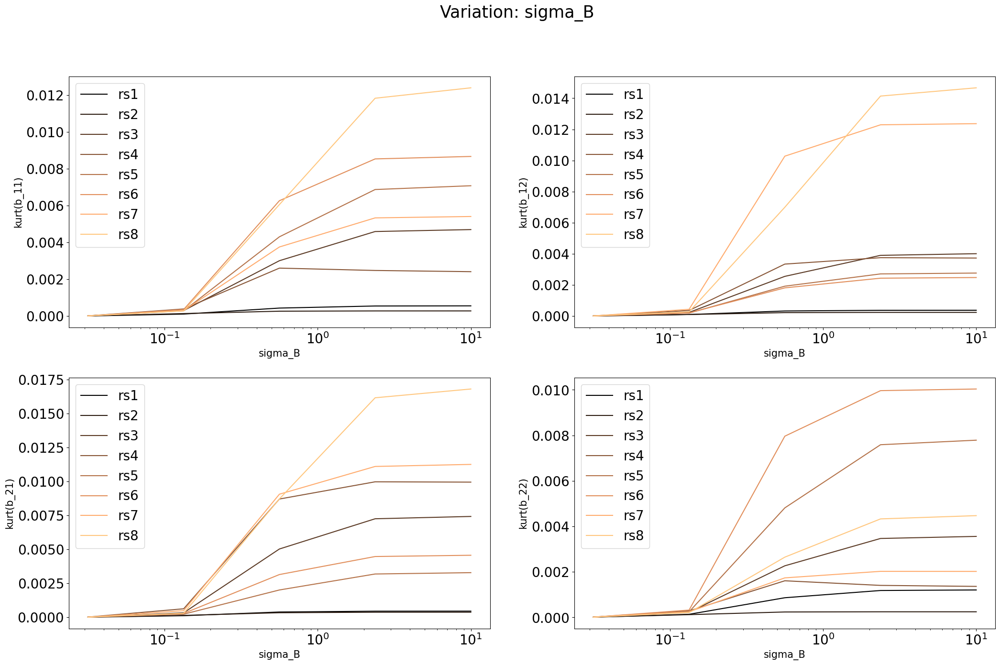

In [ ]:
VisualizationUtilities.visualize_IS_estimates(
    results_is=r['results']['prior_variation']['scale'],
    true_B=B,
    param_name='sigma_B',
)

## Variação de peso de cauda da prior

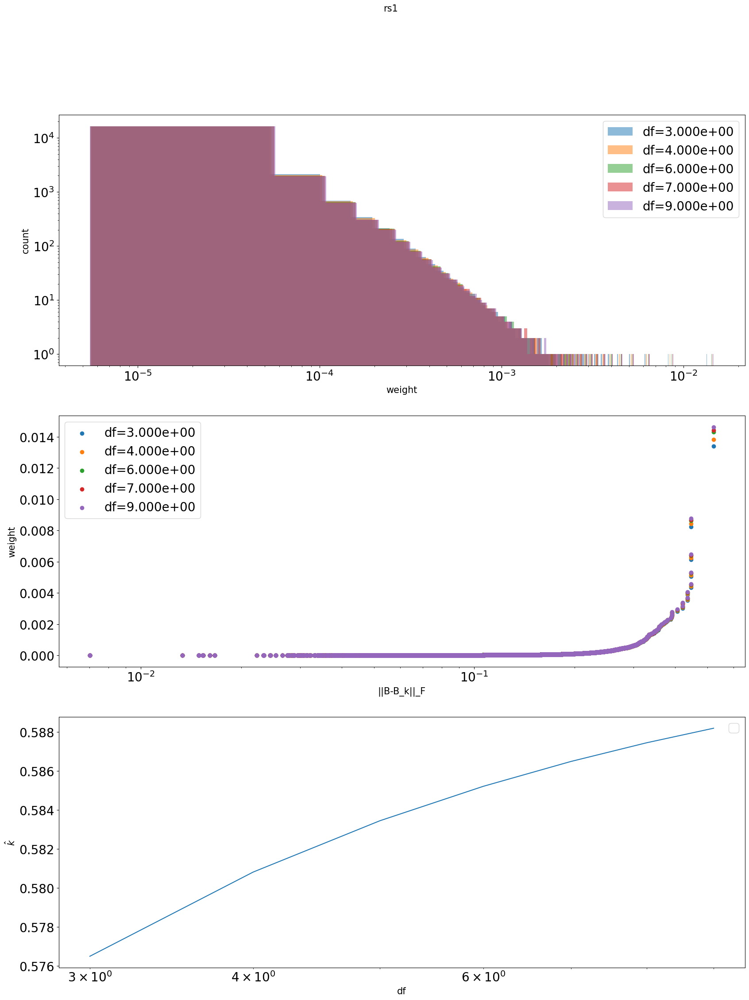

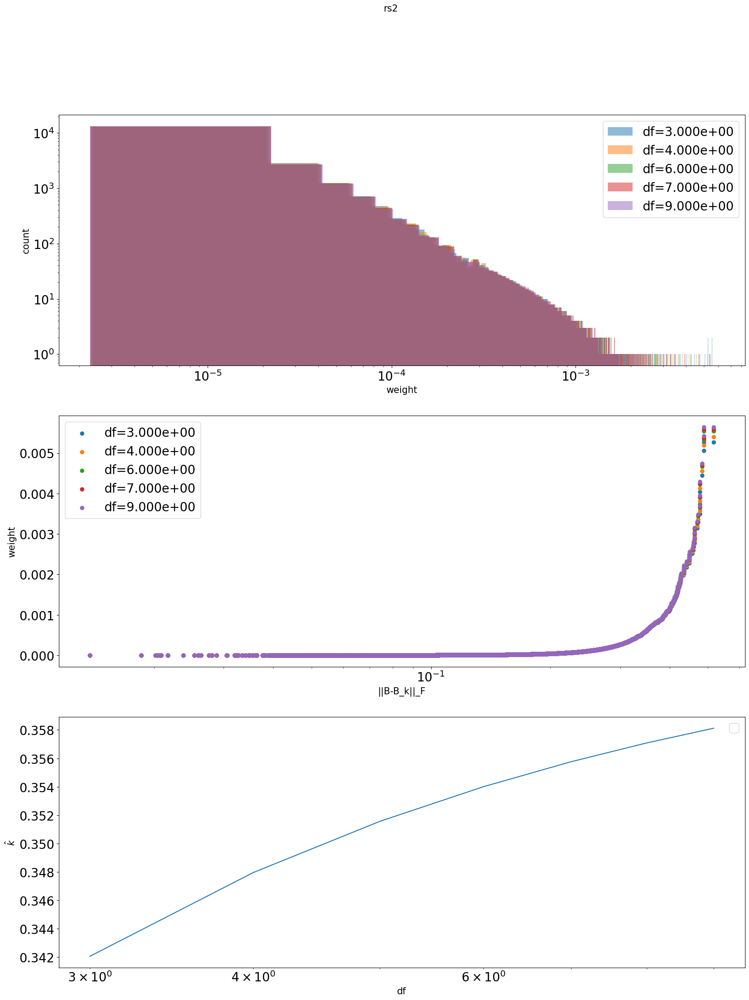

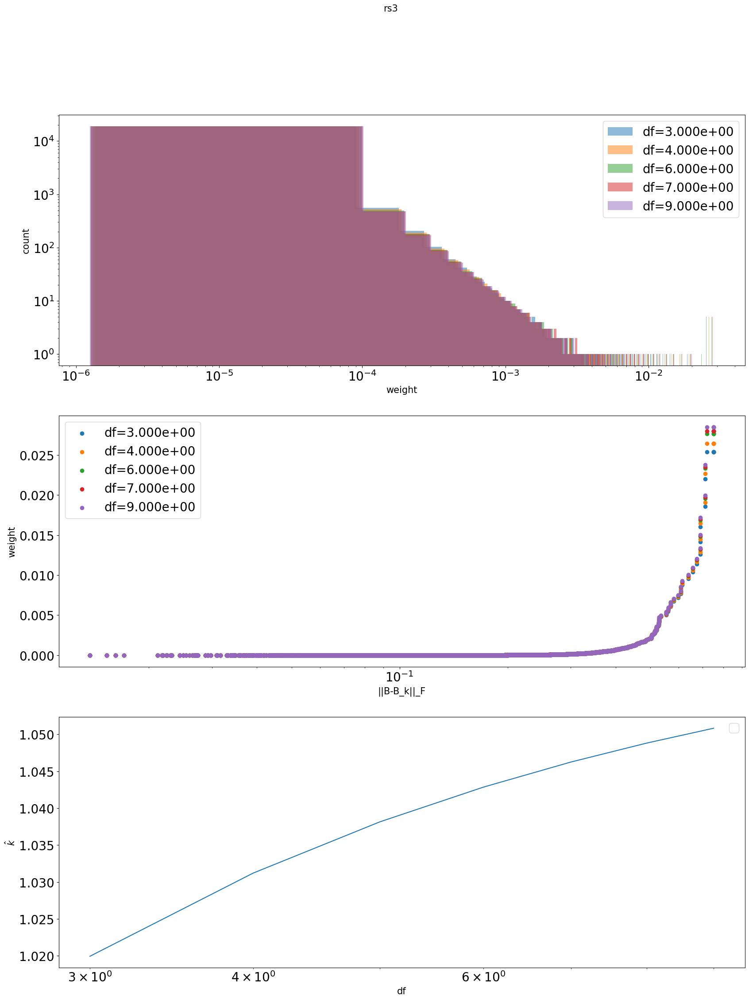

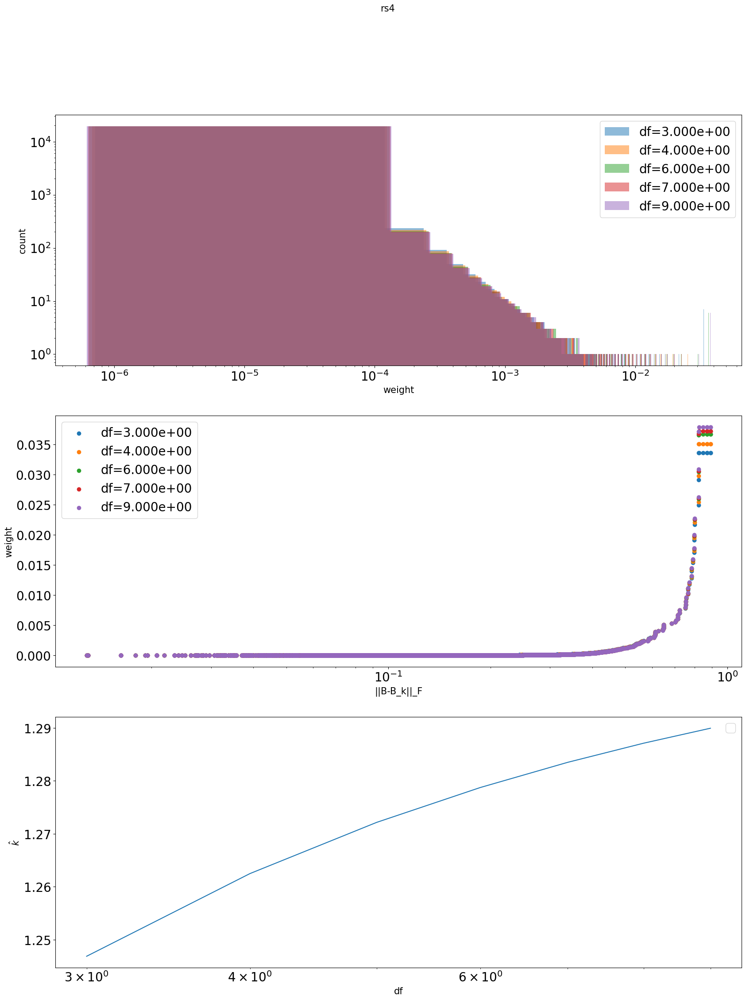

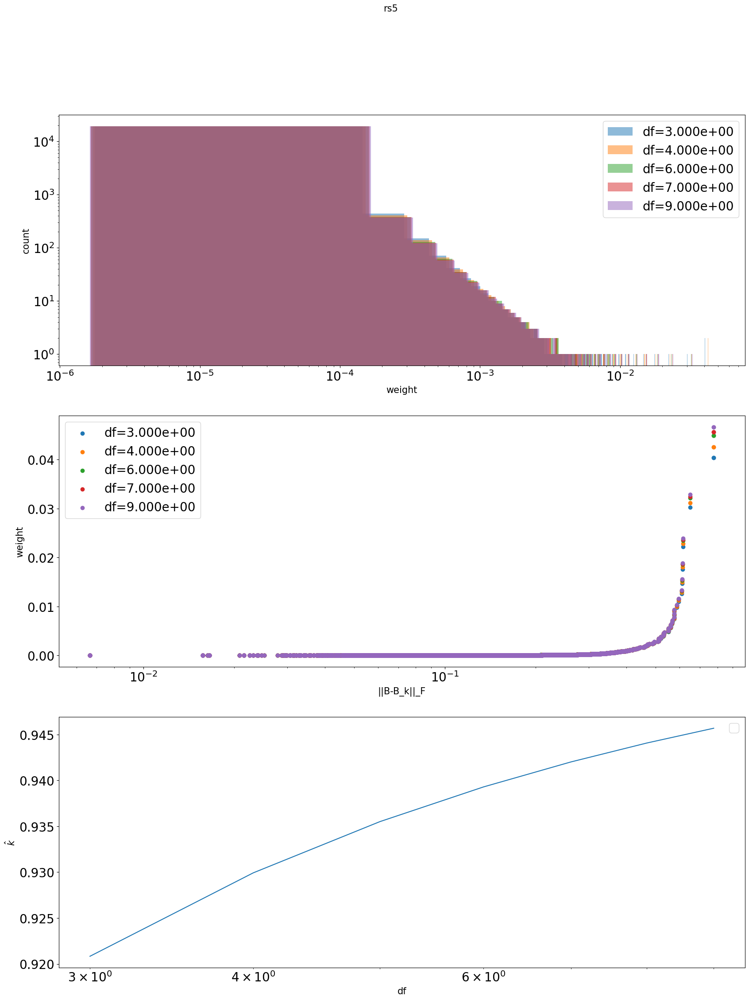

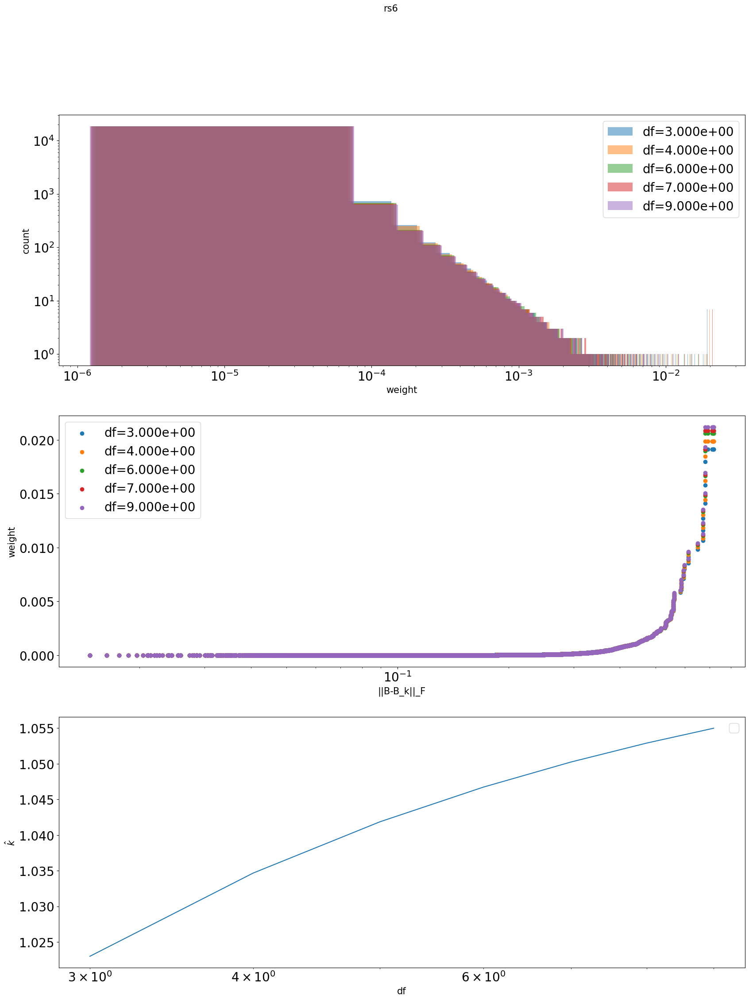

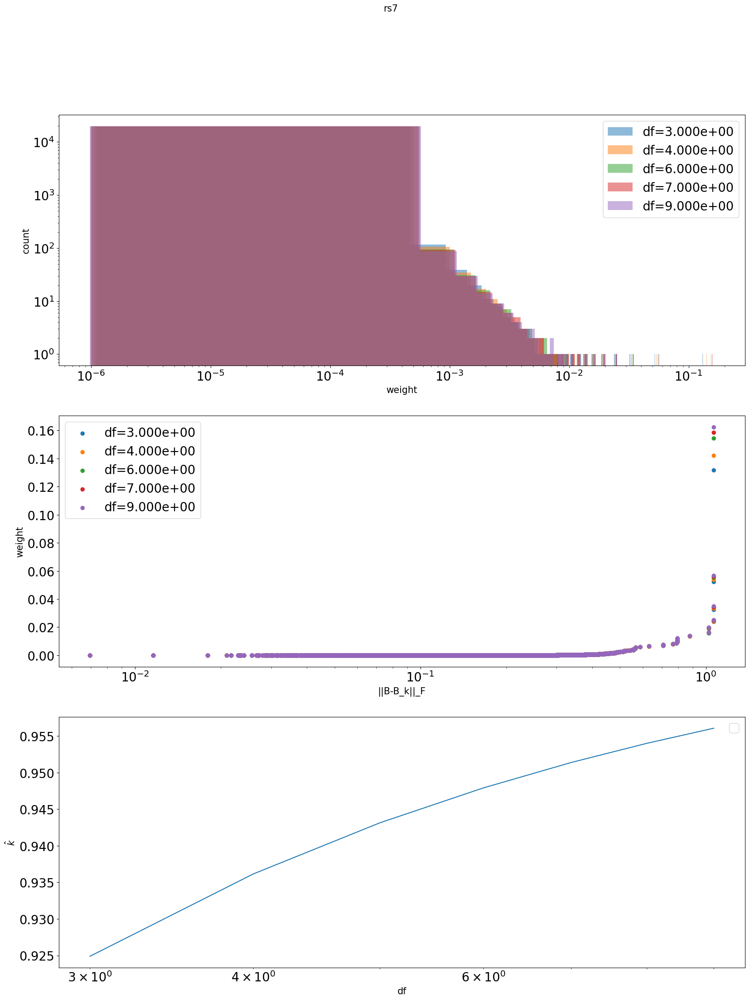

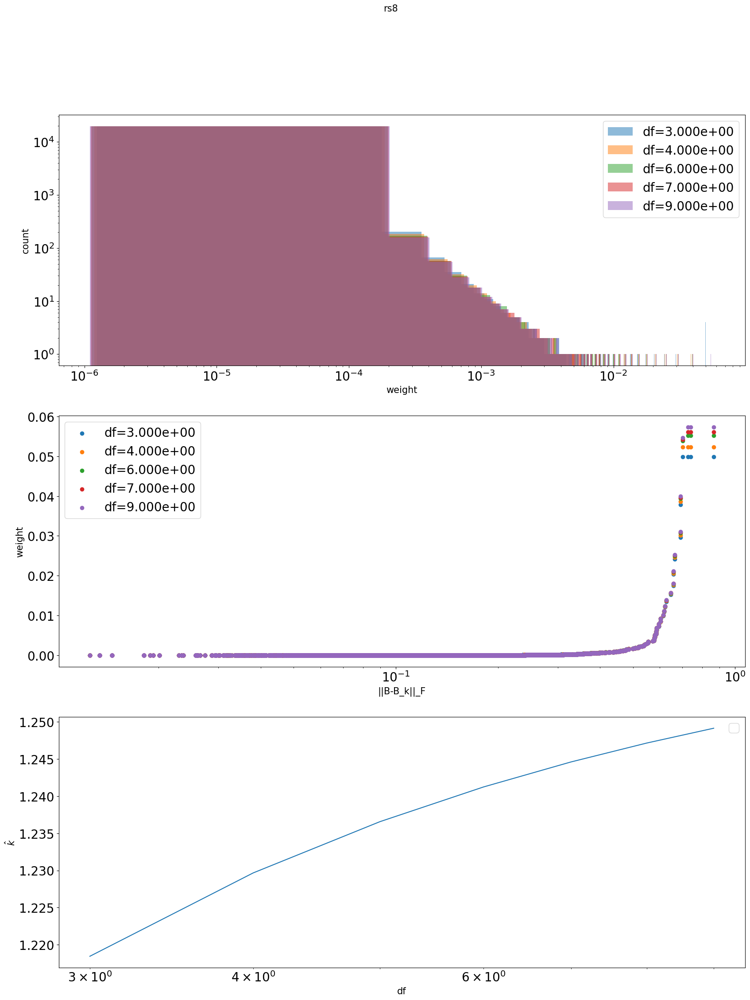

In [ ]:
VisualizationUtilities.visualize_IS_weights(
    results_is=r['results']['prior_variation']['tail_heaviness'],
    true_B=B,
    param_name='df',
    alpha=0.5,
    n_curves=5
)

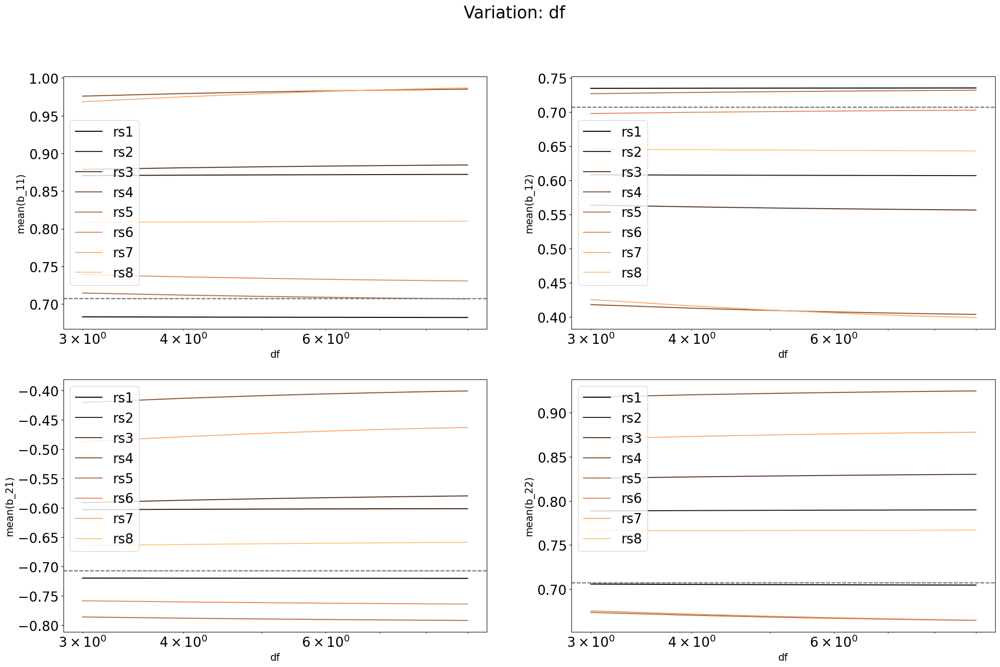

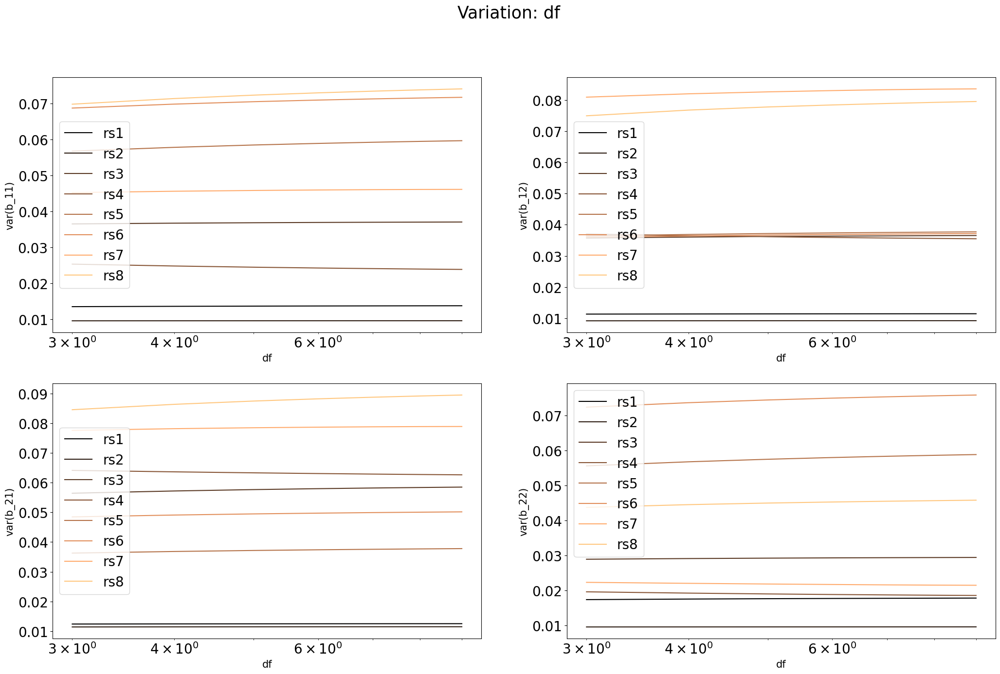

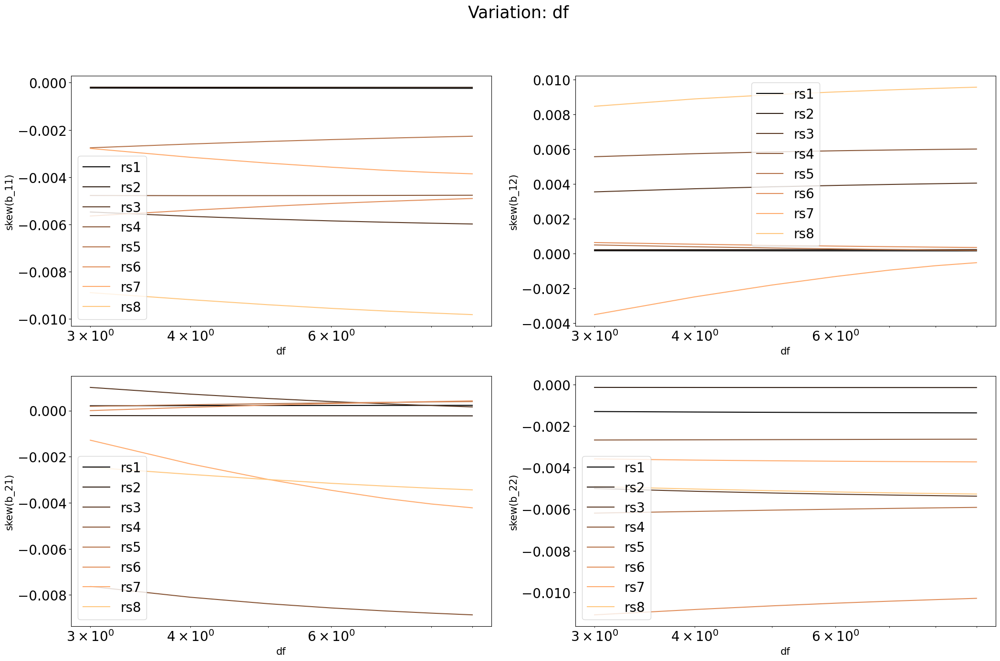

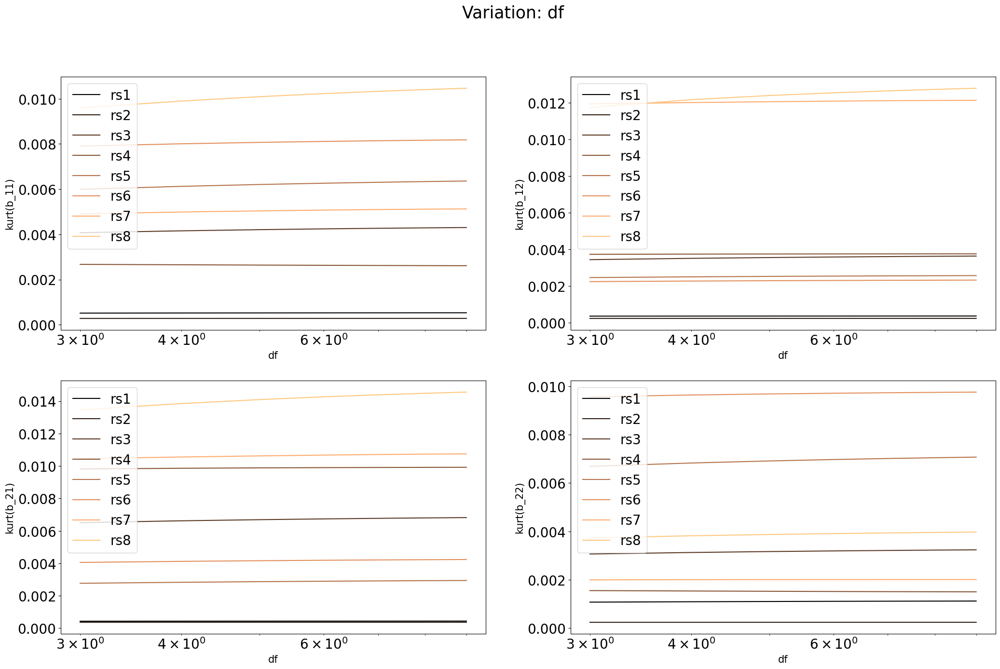

In [ ]:
VisualizationUtilities.visualize_IS_estimates(
    results_is=r['results']['prior_variation']['tail_heaviness'],
    true_B=B,
    param_name='df'
)

In [ ]:
# Run priors with different variances
target_scales = jnp.logspace(
    start=-2,
    stop=1,
    num=100,
    base=10
)
target_priors = [
    ExponentialPrior(
        center=B,
        std=sigma_B,
        use_jax=True
    ) for sigma_B in target_scales
]

results = ImportanceSamplingEstimator.run(
    samples=mmse.mcmc_results['samples'],
    baseline_prior=ExponentialPrior(
        center=B,
        std=np.inf,
    ),
    x=x,
    target_priors=target_priors,
    prior_control_params=target_scales,
    baseline_source_model=StandardLogisticSource(),
    target_source_models=None,
    source_model_control_params=None
)

NameError: name 'ImportanceSamplingEstimator' is not defined

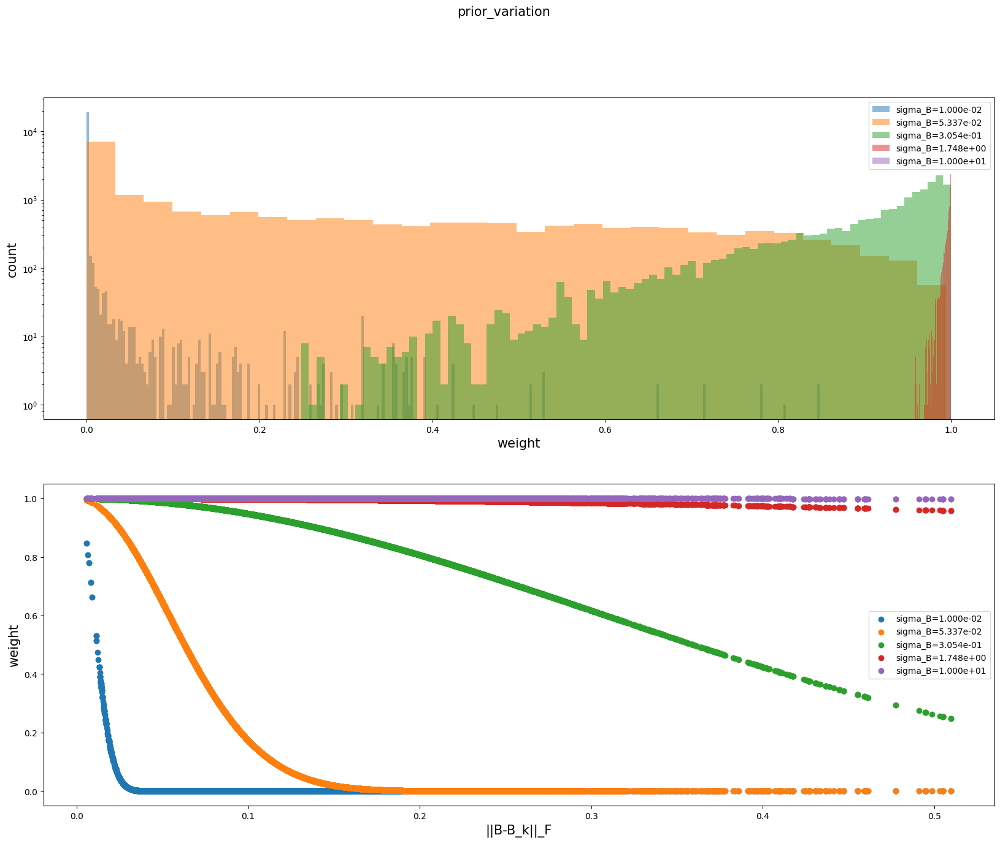

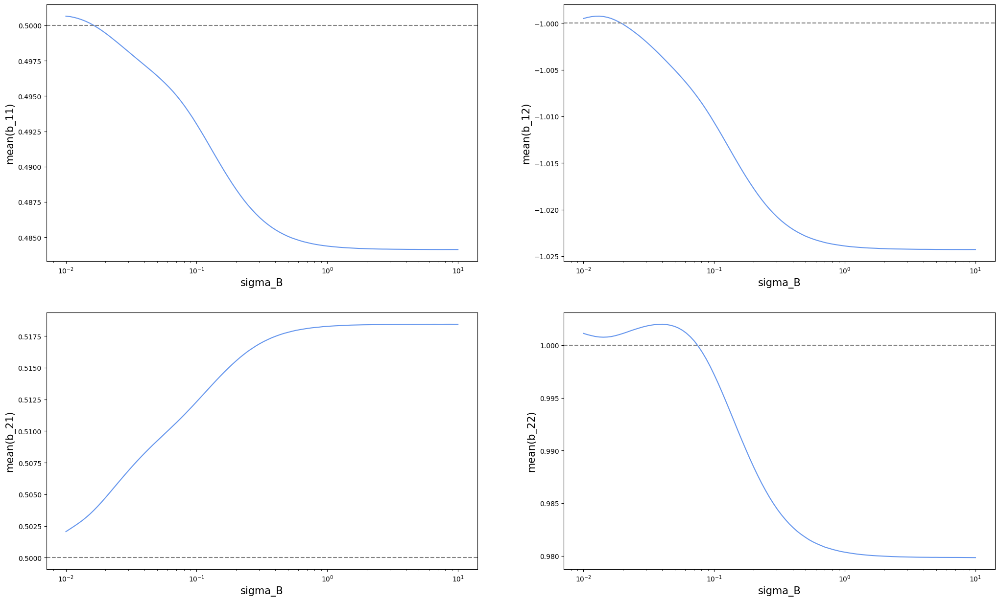

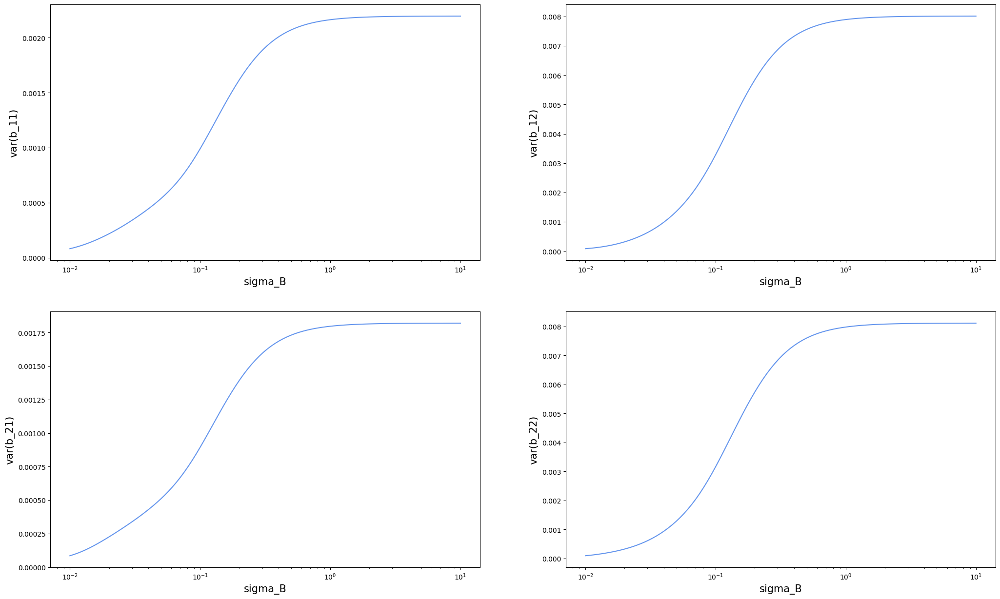

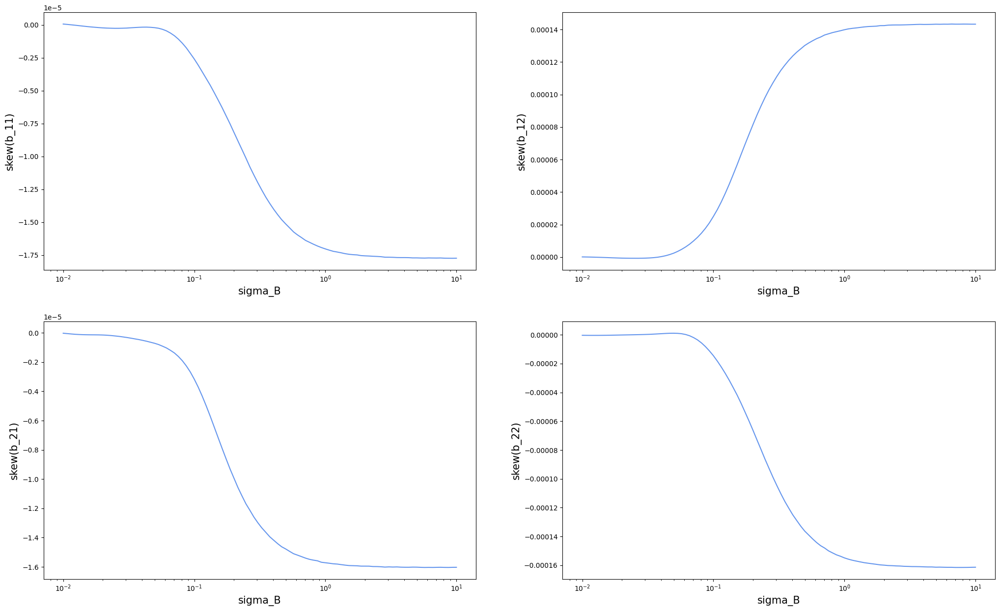

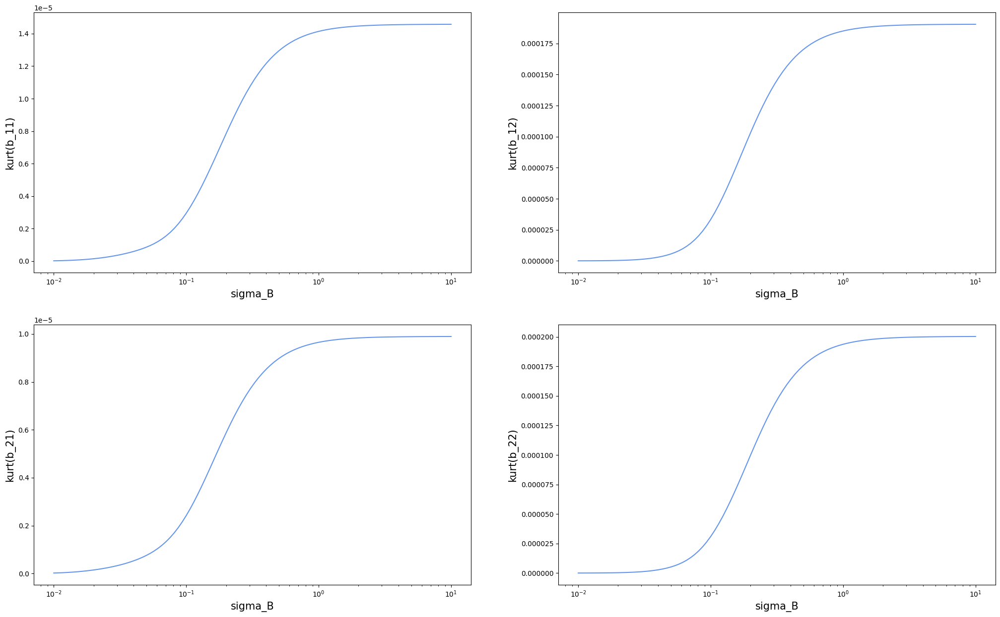

In [ ]:
visualize_estimates(
    results_is=results,
    true_B=B,
    param_name='sigma_B'
)

## Variação da moda da prior

In [ ]:
def visualize_estimate_intervals(
    results_is,
    true_B,
    param_name,
    param_threshs,
):
    # def __get_
    def __estimate_plot(
        results,
        vars_threshed,
        threshs,
        var_type,
        true_B,
        param_name
    ):

        fig, axs = plt.subplots(
            nrows=2, ncols=2,
            figsize=(25,15)
        )

        for i, j in np.ndindex(true_B.shape):
            # Get value of variable for index
            vars_threshed_values = np.array(
                [
                    np.array(arr)[:,i,j] if len(arr)>0 else np.array([]) for arr in vars_threshed[var_type+'s']
                ],
                dtype='object'
            )

            # Get statistics for each thresh value
            stats_threshed_values={}
            stats_threshed_values['max'] = [
                np.max(arr) if len(arr)>0 else np.nan for arr in vars_threshed_values
            ]
            stats_threshed_values['median'] = [
                np.median(arr) if len(arr)>0 else np.nan for arr in vars_threshed_values
            ]
            stats_threshed_values['min'] = [
                np.min(arr) if len(arr)>0 else np.nan for arr in vars_threshed_values
            ]

            # axs[i,j].set_xscale('log')
            axs[i,j].plot(
                threshs,
                stats_threshed_values['max'],
                color='cornflowerblue',
                linestyle='--',
                linewidth=.5
            )
            axs[i,j].plot(
                threshs,
                stats_threshed_values['min'],
                color='cornflowerblue',
                linestyle='--',
                linewidth=.5
            )
            axs[i,j].plot(
                threshs,
                stats_threshed_values['median'],
                color='cornflowerblue',
                linewidth=2
            )
            if var_type=='mean':
                axs[i,j].axhline(
                    true_B[i,j],
                    color='gray',
                    linestyle='--'
                )
            axs[i,j].set_xlabel(
                param_name,
                fontsize=15
            )
            axs[i,j].set_ylabel(
                '{}(b_{}{})'.format(
                    var_type,
                    i+1,
                    j+1
                ),
                fontsize=15
            )


    for analysis_type, analysis_results in results_is.items():
        # import pdb; pdb.set_trace()
        # Get samples within thresh, for each thresh
        vars_threshed = {
            v+'s': np.array(
                [
                    np.array(analysis_results[v+'s'])[
                            np.where(
                            analysis_results['params']<t
                        )[0]
                    ] for t in param_threshs
                ],
                dtype=object
            ) for v in [
                'mean',
                'var',
                'skew',
                'kurt'
            ]
        }
        # import pdb; pdb.set_trace()
        _ = [
            __estimate_plot(
                results=analysis_results,
                vars_threshed=vars_threshed,
                threshs=param_threshs,
                var_type=v,
                true_B=true_B,
                param_name=param_name
            ) for v in [
                'mean',
                'var',
                'skew',
                'kurt'
            ]
        ]

In [ ]:
# Run priors with different variances
MAX_RADIUS=1
N_PRIORS=500
modes = np.array([
    np.add(
        B,
        U
    ) for U in np.random.uniform(
        low=-MAX_RADIUS,
        high=MAX_RADIUS,
        size=(
            N_PRIORS,
            B.shape[0],
            B.shape[-1]
        )
    )
])
mode_distances = np.array([
    np.linalg.norm(
        np.subtract(B, B_k)
    ) for B_k in modes
])

target_priors = [
    ExponentialPrior(
        center=B_k,
        std=1,
        use_jax=True
    ) for B_k in modes
]

results = ImportanceSamplingEstimator.run(
    samples=mmse.mcmc_results['samples'],
    baseline_prior=ExponentialPrior(
        center=B,
        std=np.inf,
    ),
    x=x,
    target_priors=target_priors,
    prior_control_params=mode_distances,
    baseline_source_model=StandardLogisticSource(),
    target_source_models=None,
    source_model_control_params=None
)

100%|██████████| 500/500 [23:26<00:00,  2.81s/it]  


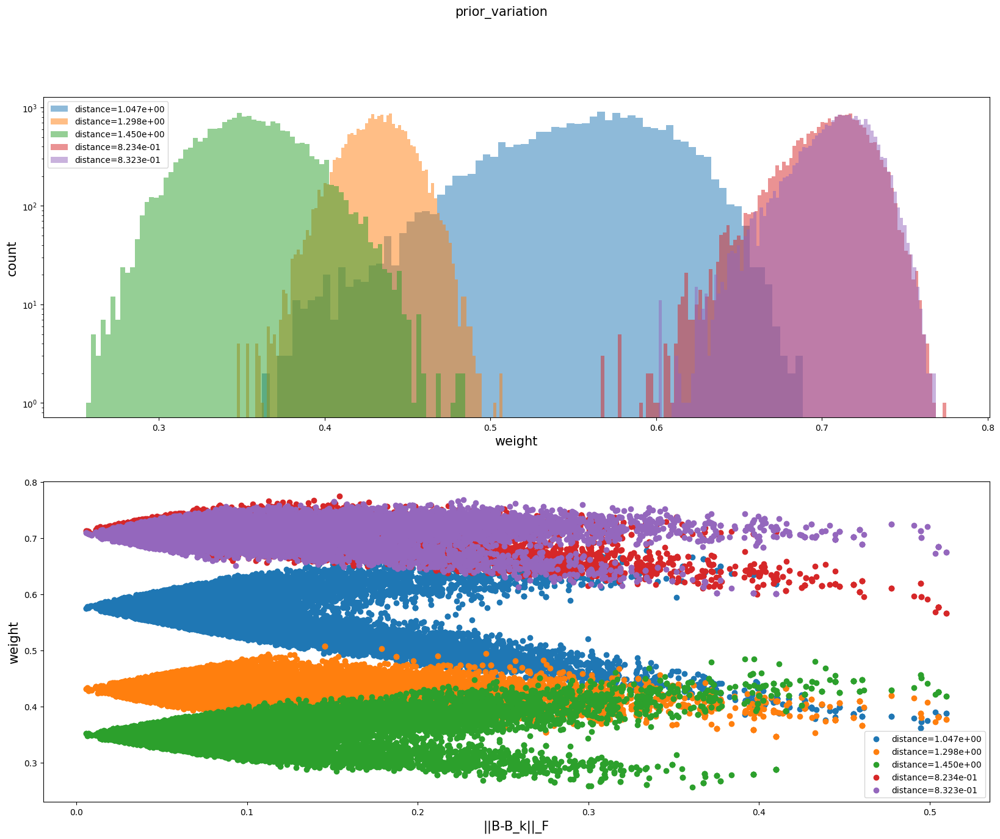

In [ ]:
visualize_weights(
    results_is=results,
    samples=mmse.mcmc_results['samples'],
    true_B=B,
    param_name='distance',
    alpha=0.5,
    n_curves=5
)

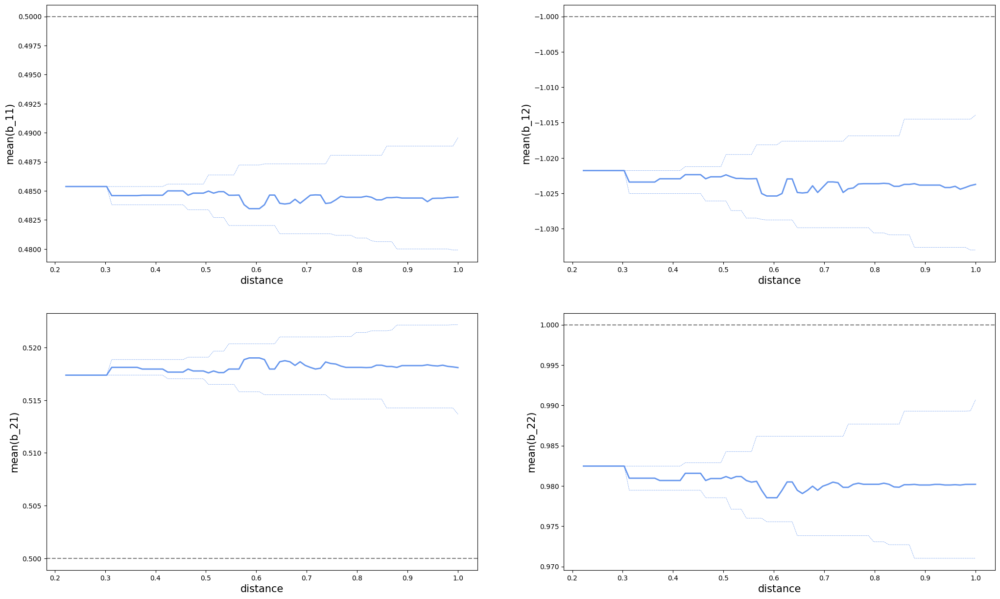

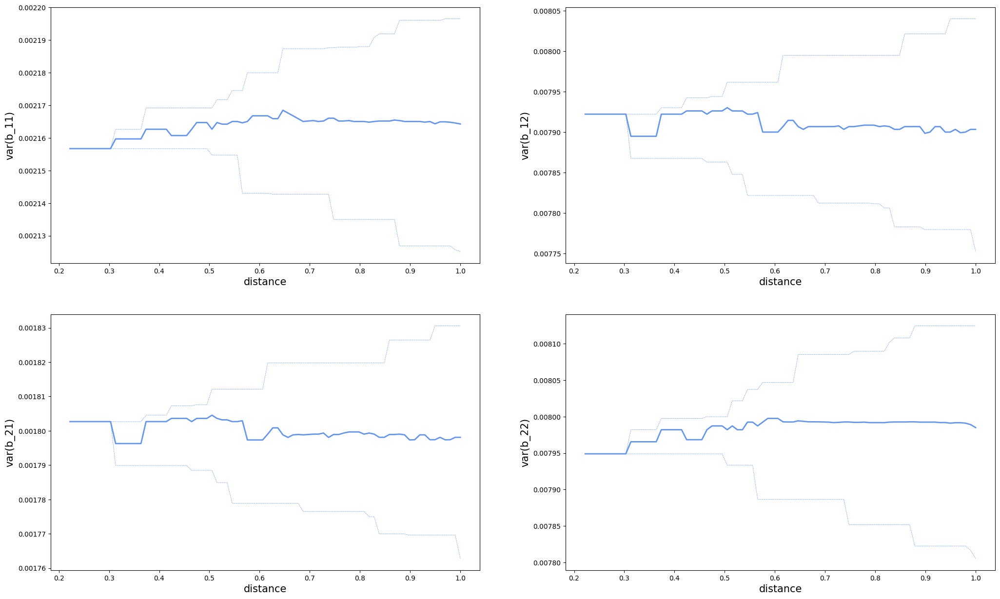

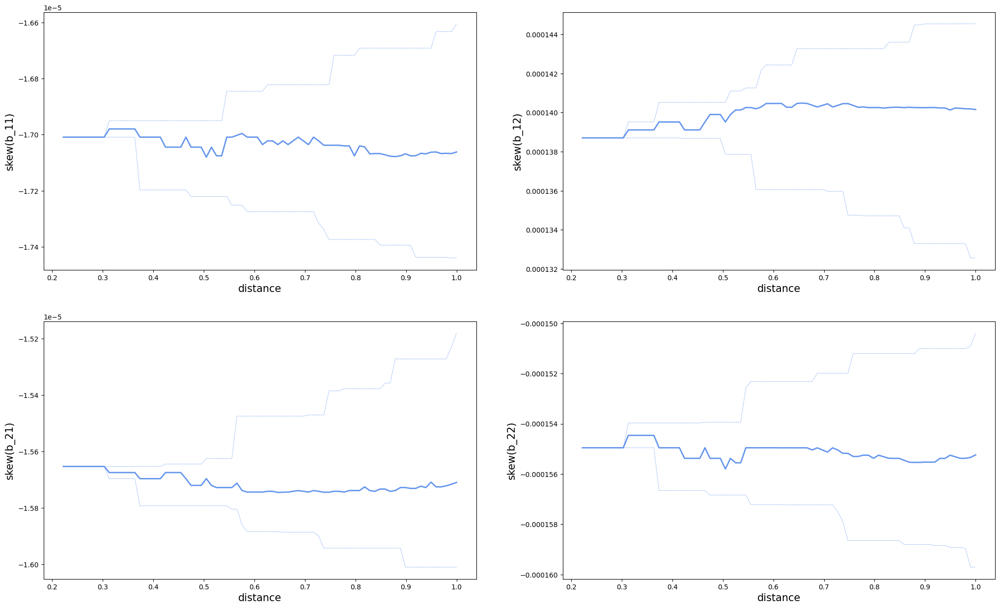

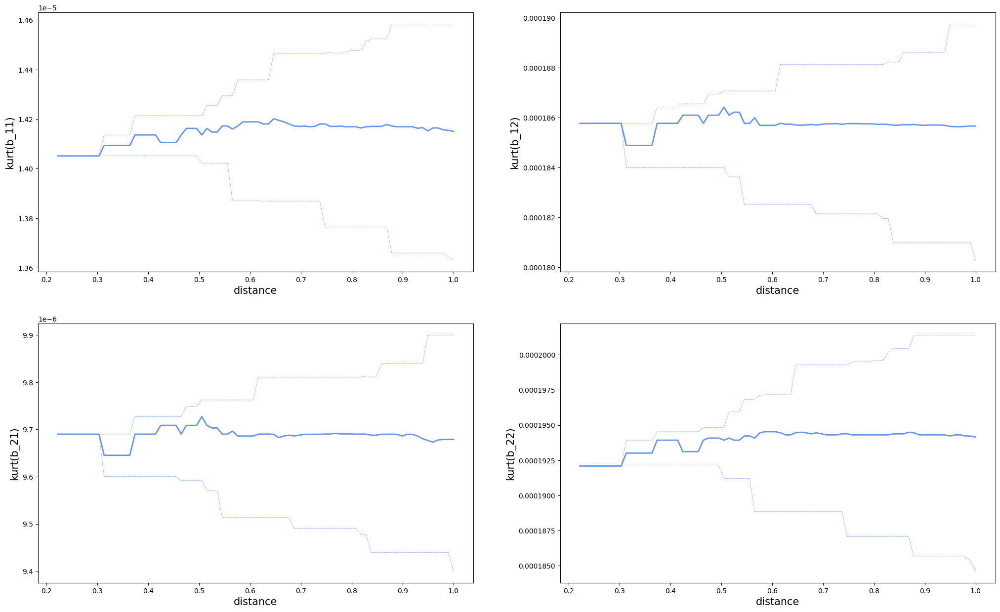

In [ ]:
dist_threshs = np.linspace(
    0,
    MAX_RADIUS,
    100
)

visualize_estimate_intervals(
    results_is=results,
    true_B=B,
    param_name='distance',
    param_threshs=dist_threshs
)